<center>


# **1. Descubrimiento de Patrones de Comorbilidad Síntoma-Enfermedad mediante Minería de Datos**

# **2. Instalación e importación de librerías**

In [ ]:
!pip install mlxtend -q

In [ ]:
"""
1. Manejo de archivos y datos
"""
import os
import zipfile
import warnings
import numpy as np
import pandas as pd

"""
2. Visualizacion
"""
import matplotlib.pyplot as plt
import seaborn as sns

"""
3. Carga de archivos en Google Colab
"""
from google.colab import files

"""
4. Reglas de asociacion
"""
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

"""
5. Clasificación y evaluación
"""
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score
"""
6. Configuración
"""
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# **3. Carga del dataset principal**

 <center>

**Disease Symptom Prediction**

<center>

**Contiene enfermedades, sintomas, descripciones, precauciones y niveles de gravedad**

**3.1 Cargar y descomprimir el archivo:**

In [ ]:
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
nombre_zip = list(uploaded.keys())[0]
with zipfile.ZipFile(nombre_zip, "r") as zip_ref: zip_ref.extractall("Disease_Symptom_Prediction")
os.listdir("Disease_Symptom_Prediction")

['archive']

**3.2 Definir la ruta:**

In [ ]:
ruta = "Disease_Symptom_Prediction/archive"

**3.3 Leer los cuatro CSV:**

In [ ]:
df = pd.read_csv(ruta + "/dataset.csv")
descripcion = pd.read_csv(ruta + "/symptom_Description.csv")
precauciones = pd.read_csv(ruta + "/symptom_precaution.csv")
gravedad = pd.read_csv(ruta + "/Symptom-severity.csv")

**3.4 Comprobar la carga:**

In [ ]:
display(df.head())
print("Dimensiones:", df.shape)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Dimensiones: (4920, 18)


# **4. Comprensión y preparación de los datos**

**4.1 Tamaño del dataset: filas y columnas**

In [ ]:
df.shape

(4920, 18)

**4.2 Informacion general del dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


**4.3 Cantidad de valores vacios por columna**

In [ ]:
df.isnull().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,348
Symptom_5,1206
Symptom_6,1986
Symptom_7,2652
Symptom_8,2976
Symptom_9,3228


**4.4 Grafico representativo**

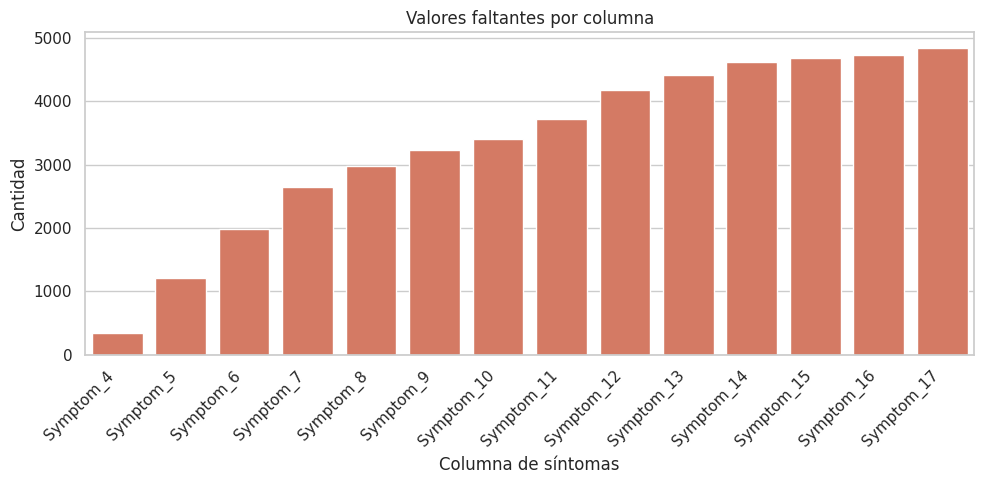

In [ ]:
faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=faltantes.index, y=faltantes.values, color="#E76F51")
plt.title("Valores faltantes por columna")
plt.xlabel("Columna de síntomas")
plt.ylabel("Cantidad")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**4.5 Cantidad de enfermedades diferentes**

In [ ]:
print("Numero de enfermedades:", df["Disease"].nunique())

Numero de enfermedades: 41


**4.6 Lista de las enfermedades**

In [ ]:
df['Disease'].unique()

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

**4.7 Cantidad de registros duplicados**

In [ ]:
print("Registros duplicados:", df.duplicated().sum())

Registros duplicados: 4616


**4.8 Gráfica representativa sin registros duplicados**

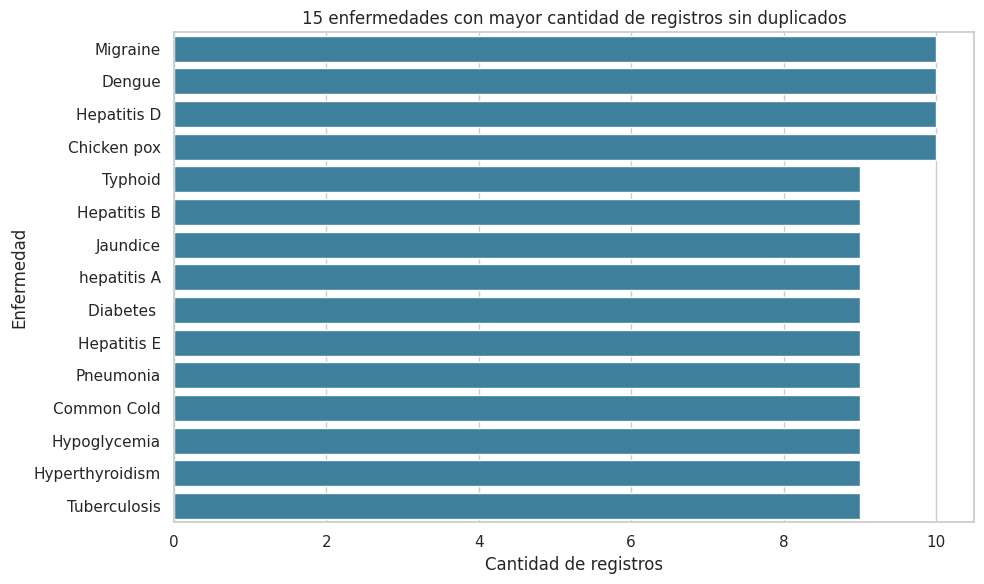

In [ ]:
frecuencia_enfermedades = df.drop_duplicates()["Disease"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=frecuencia_enfermedades.values, y=frecuencia_enfermedades.index, color="#2E86AB")

plt.title("15 enfermedades con mayor cantidad de registros sin duplicados")
plt.xlabel("Cantidad de registros")
plt.ylabel("Enfermedad")
plt.tight_layout()
plt.show()

# **5. Limpiar los datos y transformar los síntomas a formato transaccional binario**

**5.1 Limpiar nombres de síntomas**

In [ ]:
"""Crear una copia para trabajar sin modificar el dataset original"""
df_limpio = df.copy()

In [ ]:
"""Identificar columnas de síntomas"""
columnas_sintomas = [col for col in df_limpio.columns if col != "Disease"]

In [ ]:
"""Limpiar síntomas: quitar espacios, convertir a minúsculas y reemplazar espacios internos"""
for columna in columnas_sintomas:
    df_limpio[columna] = (df_limpio[columna].astype(str).str.strip().str.lower().str.replace(" ", "_"))

In [ ]:
"""Reemplazar los textos 'nan' por valores vacios reales"""
df_limpio = df_limpio.replace("nan", pd.NA)
df_limpio.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Fungal infection,itching,nodal_skin_eruptions,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Fungal infection,itching,skin_rash,dischromic__patches,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


**5.2 Crear una lista de síntomas por cada fila**

In [ ]:
columnas_sintomas = [col for col in df.columns if col != "Disease"]
df_limpio["lista_sintomas"] = df_limpio[columnas_sintomas].apply(
    lambda fila: [sintoma for sintoma in fila.dropna().tolist()],
    axis=1)
df_limpio[["Disease", "lista_sintomas"]].head()

,Disease,lista_sintomas
0,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions, dis..."
1,Fungal infection,"[skin_rash, nodal_skin_eruptions, dischromic__..."
2,Fungal infection,"[itching, nodal_skin_eruptions, dischromic__pa..."
3,Fungal infection,"[itching, skin_rash, dischromic__patches]"
4,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions]"


**5.3 Eliminar registros duplicados**

In [ ]:
"""Registros antes de eliminar los Duplicados"""
print("Registros originales:", len(df_limpio))

Registros originales: 4920


In [ ]:
columnas_para_duplicados = ["Disease"] + columnas_sintomas

df_limpio_sin_dup = df_limpio[columnas_para_duplicados].drop_duplicates().reset_index(drop=True).copy()

df_limpio_sin_dup["lista_sintomas"] = df_limpio_sin_dup[columnas_sintomas].apply(
    lambda fila: fila.dropna().tolist(), axis=1
)

frecuencia_sintomas = df_limpio_sin_dup["lista_sintomas"].explode().value_counts().head(20)

frecuencia_sintomas

,count
lista_sintomas,
fatigue,134
vomiting,117
high_fever,89
loss_of_appetite,81
nausea,77
headache,74
abdominal_pain,70
yellowish_skin,61
yellowing_of_eyes,58


**5.4 Grafico representativo de simtomas mas frecuentes**

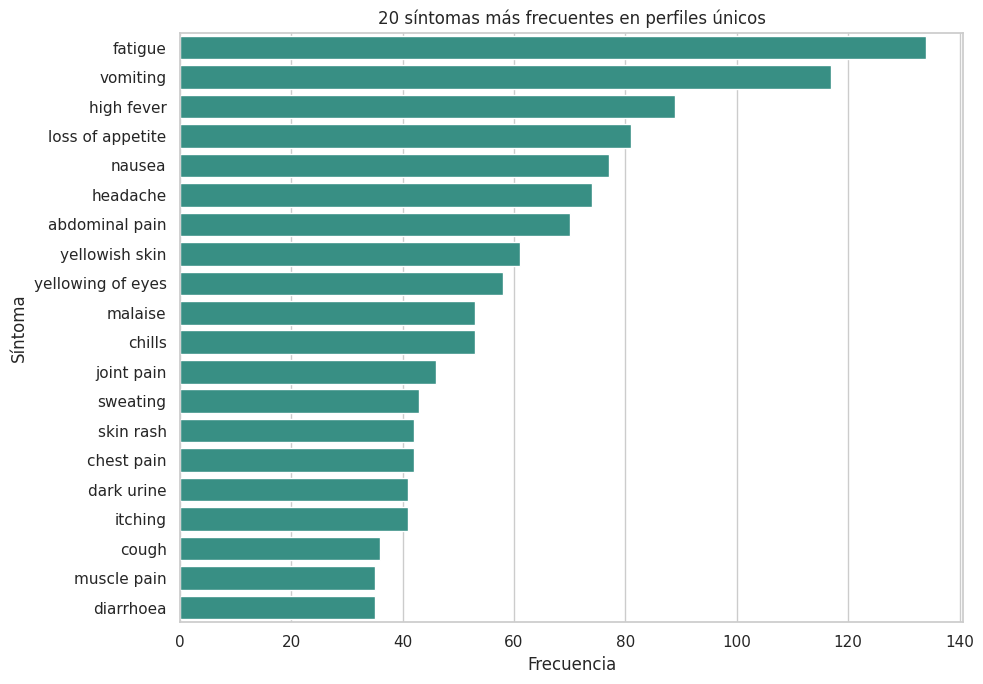

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x=frecuencia_sintomas.values, y=frecuencia_sintomas.index.str.replace("_", " "), color="#2A9D8F")
plt.title("20 síntomas más frecuentes en perfiles únicos")
plt.xlabel("Frecuencia")
plt.ylabel("Síntoma")
plt.tight_layout()
plt.show()

In [ ]:
"""Registros despues de eliminar duplicados"""
print("Registros sin duplicados:", len(df_limpio_sin_dup))

Registros sin duplicados: 304


In [ ]:
"""Cantidad de registros duplicados eliminados"""
print("Duplicados eliminados:", len(df_limpio) - len(df_limpio_sin_dup))

Duplicados eliminados: 4616


In [ ]:
"""Mostrar los registros"""
df_limpio_sin_dup[["Disease", "lista_sintomas"]].head()

,Disease,lista_sintomas
0,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions, dis..."
1,Fungal infection,"[skin_rash, nodal_skin_eruptions, dischromic__..."
2,Fungal infection,"[itching, nodal_skin_eruptions, dischromic__pa..."
3,Fungal infection,"[itching, skin_rash, dischromic__patches]"
4,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions]"


<center>

Se eliminaron registros idénticos para evitar que su repetición aumentara artificialmente el soporte, la confianza y la exactitud. El análisis final utiliza perfiles únicos de síntomas y enfermedad.

# **6. Descubrimiento de patrones frecuentes de síntomas asociados a enfermedades mediante el algoritmo Apriori**

**6.1 Crear transacciones con síntomas + enfermedad**

In [ ]:
df_apriori = df_limpio_sin_dup.copy()
df_apriori["Disease_item"] = ("disease_" + df_apriori["Disease"].str.lower().str.strip().str.replace(" ", "_"))
df_apriori["transaccion"] = df_apriori["lista_sintomas"] + df_apriori["Disease_item"].apply(lambda x: [x])
df_apriori[["Disease", "transaccion"]].head()

,Disease,transaccion
0,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions, dis..."
1,Fungal infection,"[skin_rash, nodal_skin_eruptions, dischromic__..."
2,Fungal infection,"[itching, nodal_skin_eruptions, dischromic__pa..."
3,Fungal infection,"[itching, skin_rash, dischromic__patches, dise..."
4,Fungal infection,"[itching, skin_rash, nodal_skin_eruptions, dis..."


**6.2 Convertir esas transacciones a formato binario**

In [ ]:
te_apriori = TransactionEncoder()
transacciones_codificadas = te_apriori.fit(df_apriori["transaccion"]).transform(df_apriori["transaccion"])
df_transacciones = pd.DataFrame(transacciones_codificadas, columns=te_apriori.columns_)


**6.3 Aplicar Apriori con primera configuración**

In [ ]:
"""Esta configuracion busca reglas mas generales"""
itemsets_1 = apriori(df_transacciones, min_support=0.05, use_colnames=True, max_len=3,low_memory=True)
reglas_1 = association_rules(itemsets_1, metric="confidence", min_threshold=0.60)
reglas_1.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
412,"(headache, loss_of_appetite)",(red_spots_over_body),0.059211,0.062500,0.055921,0.944444,15.111111,1.0,0.052220,16.875000,0.992596,0.850000,0.940741,0.919591
415,(red_spots_over_body),"(headache, loss_of_appetite)",0.062500,0.059211,0.055921,0.894737,15.111111,1.0,0.052220,8.937500,0.996078,0.850000,0.888112,0.919591
431,(red_spots_over_body),"(headache, skin_rash)",0.062500,0.055921,0.052632,0.842105,15.058824,1.0,0.049137,5.979167,0.995833,0.800000,0.832753,0.891641
428,"(headache, skin_rash)",(red_spots_over_body),0.055921,0.062500,0.052632,0.941176,15.058824,1.0,0.049137,15.937500,0.988894,0.800000,0.937255,0.891641
506,"(skin_rash, loss_of_appetite)",(red_spots_over_body),0.055921,0.062500,0.052632,0.941176,15.058824,1.0,0.049137,15.937500,0.988894,0.800000,0.937255,0.891641
509,(red_spots_over_body),"(skin_rash, loss_of_appetite)",0.062500,0.055921,0.052632,0.842105,15.058824,1.0,0.049137,5.979167,0.995833,0.800000,0.832753,0.891641
532,"(skin_rash, malaise)",(red_spots_over_body),0.055921,0.062500,0.052632,0.941176,15.058824,1.0,0.049137,15.937500,0.988894,0.800000,0.937255,0.891641
534,(red_spots_over_body),"(skin_rash, malaise)",0.062500,0.055921,0.052632,0.842105,15.058824,1.0,0.049137,5.979167,0.995833,0.800000,0.832753,0.891641
217,"(chest_pain, swelled_lymph_nodes)",(phlegm),0.055921,0.085526,0.055921,1.000000,11.692308,1.0,0.051138,inf,0.968641,0.653846,1.000000,0.826923
218,(phlegm),"(chest_pain, swelled_lymph_nodes)",0.085526,0.055921,0.055921,0.653846,11.692308,1.0,0.051138,2.727339,1.000000,0.653846,0.633342,0.826923


**6.4 Aplicar Apriori con segunda configuración**

In [ ]:
itemsets_2 = apriori(df_transacciones, min_support=0.01, use_colnames=True, max_len=4, low_memory=True)
reglas_2 = association_rules(itemsets_2, metric="confidence", min_threshold=0.50)
reglas_2.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
761,(disease_urinary_tract_infection),(foul_smell_of_urine),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9
715,(disease_paralysis_(brain_hemorrhage)),(weakness_of_one_body_side),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9
716,(weakness_of_one_body_side),(disease_paralysis_(brain_hemorrhage)),0.013158,0.016447,0.013158,1.0,60.8,1.0,0.012941,inf,0.996667,0.8,1.000000,0.9
131,(disease_acne),(blackheads),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9
132,(blackheads),(disease_acne),0.013158,0.016447,0.013158,1.0,60.8,1.0,0.012941,inf,0.996667,0.8,1.000000,0.9
133,(bladder_discomfort),(disease_urinary_tract_infection),0.013158,0.016447,0.013158,1.0,60.8,1.0,0.012941,inf,0.996667,0.8,1.000000,0.9
134,(disease_urinary_tract_infection),(bladder_discomfort),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9
82,(disease_paralysis_(brain_hemorrhage)),(altered_sensorium),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9
762,(foul_smell_of_urine),(disease_urinary_tract_infection),0.013158,0.016447,0.013158,1.0,60.8,1.0,0.012941,inf,0.996667,0.8,1.000000,0.9
479,(disease_allergy),(shivering),0.016447,0.013158,0.013158,0.8,60.8,1.0,0.012941,4.934211,1.000000,0.8,0.797333,0.9


In [ ]:
[col for col in df_transacciones.columns if col.startswith("disease_")][:10]

['disease_(vertigo)_paroymsal__positional_vertigo',
 'disease_acne',
 'disease_aids',
 'disease_alcoholic_hepatitis',
 'disease_allergy',
 'disease_arthritis',
 'disease_bronchial_asthma',
 'disease_cervical_spondylosis',
 'disease_chicken_pox',
 'disease_chronic_cholestasis']


**6.5 Comparación de configuraciones de Apriori**

In [ ]:
comparacion_apriori = pd.DataFrame({
    "Configuración": ["Primera", "Segunda"],
    "Soporte mínimo": [0.05, 0.01],
    "Confianza mínima": [0.60, 0.50],
    "Itemsets encontrados": [len(itemsets_1), len(itemsets_2)],
    "Reglas encontradas": [len(reglas_1), len(reglas_2)]
})

comparacion_apriori

,Configuración,Soporte mínimo,Confianza mínima,Itemsets encontrados,Reglas encontradas
0,Primera,0.05,0.6,365,549
1,Segunda,0.01,0.5,19645,136722


**6.6 Grafico representativo**

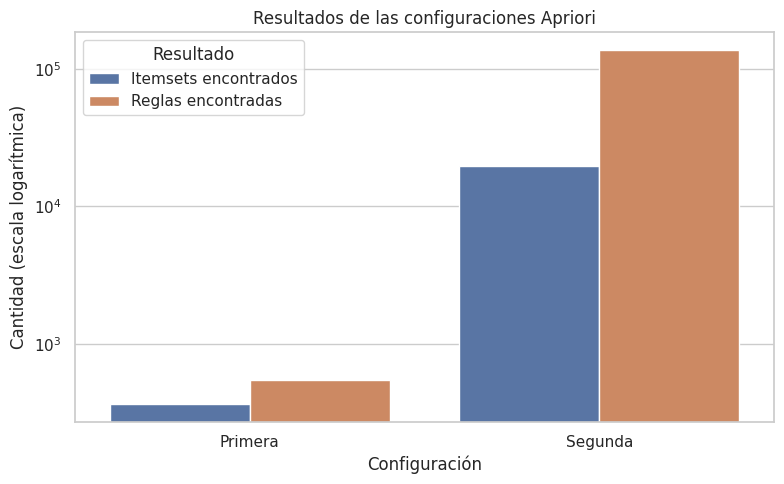

In [ ]:
datos_grafico_apriori = comparacion_apriori.melt(
    id_vars="Configuración",
    value_vars=["Itemsets encontrados", "Reglas encontradas"],
    var_name="Resultado",
    value_name="Cantidad"
)

plt.figure(figsize=(8, 5))
sns.barplot(data=datos_grafico_apriori, x="Configuración", y="Cantidad", hue="Resultado")
plt.yscale("log")
plt.title("Resultados de las configuraciones Apriori")
plt.ylabel("Cantidad (escala logarítmica)")
plt.tight_layout()
plt.show()

**6.7 Filtrar reglas cuyo resultado sea una enfermedad**

In [ ]:
reglas_enfermedad = reglas_2[reglas_2["consequents"].apply(lambda x: len(x) == 1 and list(x)[0].startswith("disease_"))].copy()
reglas_enfermedad = reglas_enfermedad.sort_values(by=["lift", "confidence", "support"], ascending=False)
reglas_enfermedad[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

,antecedents,consequents,support,confidence,lift
83,(altered_sensorium),(disease_paralysis_(brain_hemorrhage)),0.013158,1.0,60.8
132,(blackheads),(disease_acne),0.013158,1.0,60.8
133,(bladder_discomfort),(disease_urinary_tract_infection),0.013158,1.0,60.8
355,(continuous_feel_of_urine),(disease_urinary_tract_infection),0.013158,1.0,60.8
425,(dehydration),(disease_gastroenteritis),0.013158,1.0,60.8
447,(dischromic__patches),(disease_fungal_infection),0.013158,1.0,60.8
457,(pus_filled_pimples),(disease_acne),0.013158,1.0,60.8
460,(scurring),(disease_acne),0.013158,1.0,60.8
463,(extra_marital_contacts),(disease_aids),0.013158,1.0,60.8
465,(muscle_wasting),(disease_aids),0.013158,1.0,60.8


**6.8 Filtrar reglas con 2 o más síntomas**

In [ ]:
reglas_enfermedad_multi = reglas_enfermedad[reglas_enfermedad["antecedents"].apply(lambda x: len(x) >= 2)].copy()
reglas_enfermedad_multi[["antecedents", "consequents", "support", "confidence", "lift"]].head(15)

,antecedents,consequents,support,confidence,lift
3235,"(dizziness, back_pain)",(disease_cervical_spondylosis),0.013158,1.0,50.666667
3239,"(back_pain, loss_of_balance)",(disease_cervical_spondylosis),0.013158,1.0,50.666667
3243,"(neck_pain, back_pain)",(disease_cervical_spondylosis),0.013158,1.0,50.666667
3247,"(weakness_in_limbs, back_pain)",(disease_cervical_spondylosis),0.013158,1.0,50.666667
3741,"(high_fever, blister)",(disease_impetigo),0.013158,1.0,50.666667
3746,"(red_sore_around_nose, blister)",(disease_impetigo),0.013158,1.0,50.666667
3752,"(skin_rash, blister)",(disease_impetigo),0.013158,1.0,50.666667
3757,"(yellow_crust_ooze, blister)",(disease_impetigo),0.013158,1.0,50.666667
4211,"(bloody_stool, constipation)",(disease_dimorphic_hemmorhoids(piles)),0.013158,1.0,50.666667
4216,"(bloody_stool, irritation_in_anus)",(disease_dimorphic_hemmorhoids(piles)),0.013158,1.0,50.666667


**6.9 Convertir reglas a texto**

In [ ]:
def convertir_regla_texto(regla):
    antecedentes = ", ".join(list(regla["antecedents"])).replace("_", " ")
    consecuentes = ", ".join(list(regla["consequents"])).replace("disease_", "").replace("_", " ")
    return antecedentes + " -> " + consecuentes.title()

reglas_enfermedad_multi["regla"] = reglas_enfermedad_multi.apply(convertir_regla_texto, axis=1)
reglas_resultado = reglas_enfermedad_multi[["regla", "support", "confidence", "lift"]].copy()

reglas_resultado["support"] = reglas_resultado["support"].round(3)
reglas_resultado["confidence"] = reglas_resultado["confidence"].round(3)
reglas_resultado["lift"] = reglas_resultado["lift"].round(3)
reglas_resultado.head(15)

,regla,support,confidence,lift
3235,"dizziness, back pain -> Cervical Spondylosis",0.013,1.0,50.667
3239,"back pain, loss of balance -> Cervical Spondyl...",0.013,1.0,50.667
3243,"neck pain, back pain -> Cervical Spondylosis",0.013,1.0,50.667
3247,"weakness in limbs, back pain -> Cervical Spond...",0.013,1.0,50.667
3741,"high fever, blister -> Impetigo",0.013,1.0,50.667
3746,"red sore around nose, blister -> Impetigo",0.013,1.0,50.667
3752,"skin rash, blister -> Impetigo",0.013,1.0,50.667
3757,"yellow crust ooze, blister -> Impetigo",0.013,1.0,50.667
4211,"bloody stool, constipation -> Dimorphic Hemmor...",0.013,1.0,50.667
4216,"bloody stool, irritation in anus -> Dimorphic ...",0.013,1.0,50.667


# **7. Seleccionar las 10 a 15 reglas más relevantes**

**7.1 Filtrar, ordenar y seleccionar las mejores 15 reglas**

In [ ]:
"""1. Crear una copia de las reglas candidatas"""
reglas_candidatas = reglas_enfermedad_multi.copy()
"""2.Extraer el nombre de la enfermedad del consecuente"""
reglas_candidatas["Enfermedad_item"] = (reglas_candidatas["consequents"].apply(lambda conjunto: list(conjunto)[0]))
"""3. Aplicar criterios mínimos de calidad"""
reglas_candidatas = reglas_candidatas[(reglas_candidatas["lift"] > 1)
& (reglas_candidatas["confidence"] >= 0.60) & (reglas_candidatas["support"] >= 0.01)]
"""4. Ordenar las reglas desde las más relevantes"""
reglas_candidatas = reglas_candidatas.sort_values(by=["lift", "confidence", "support"], ascending=False)
"""5. Seleccionar una regla por enfermedad y tomar hasta 15 reglas"""
reglas_finales = (reglas_candidatas.groupby("Enfermedad_item", group_keys=False).head(1).head(15).copy())

print("Reglas seleccionadas:", len(reglas_finales))
print("Enfermedades diferentes:",reglas_finales["Enfermedad_item"].nunique())

reglas_finales[["antecedents", "consequents", "support", "confidence", "lift"]]

Reglas seleccionadas: 15
Enfermedades diferentes: 15


,antecedents,consequents,support,confidence,lift
3235,"(dizziness, back_pain)",(disease_cervical_spondylosis),0.013158,1.0,50.666667
3741,"(high_fever, blister)",(disease_impetigo),0.013158,1.0,50.666667
4211,"(bloody_stool, constipation)",(disease_dimorphic_hemmorhoids(piles)),0.013158,1.0,50.666667
5463,"(burning_micturition, itching)",(disease_drug_reaction),0.013158,1.0,50.666667
5805,"(dizziness, chest_pain)",(disease_hypertension),0.013158,1.0,50.666667
10205,"(movement_stiffness, muscle_weakness)",(disease_arthritis),0.013158,1.0,50.666667
1629,"(indigestion, abdominal_pain)",(disease_peptic_ulcer_diseae),0.016447,1.0,43.428571
2482,"(chest_pain, acidity)",(disease_gerd),0.016447,1.0,43.428571
4781,"(breathlessness, family_history)",(disease_bronchial_asthma),0.016447,1.0,43.428571
10065,"(spinning_movements, headache)",(disease_(vertigo)_paroymsal__positional_vertigo),0.016447,1.0,43.428571


**7.2 Crear una tabla y seleccionar las mejores 15 reglas**

In [ ]:
def limpiar_sintomas(sintomas):
    return ", ".join(sorted(sintomas)).replace("_", " ")

def limpiar_enfermedad(consecuente):
    return list(consecuente)[0].replace("disease_", "").replace("_", " ").title()

tabla_reglas_finales = reglas_finales[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

tabla_reglas_finales["Síntomas asociados"] = tabla_reglas_finales["antecedents"].apply(limpiar_sintomas)
tabla_reglas_finales["Enfermedad"] = tabla_reglas_finales["consequents"].apply(limpiar_enfermedad)
tabla_reglas_finales["Soporte"] = tabla_reglas_finales["support"].round(3)
tabla_reglas_finales["Confianza"] = tabla_reglas_finales["confidence"].round(3)
tabla_reglas_finales["Lift"] = tabla_reglas_finales["lift"].round(3)

tabla_reglas_finales = tabla_reglas_finales[
    ["Síntomas asociados", "Enfermedad", "Soporte", "Confianza", "Lift"]
].reset_index(drop=True)

tabla_reglas_finales.index += 1
tabla_reglas_finales.index.name = "Regla"

tabla_reglas_finales

,Síntomas asociados,Enfermedad,Soporte,Confianza,Lift
Regla,,,,,
1,"back pain, dizziness",Cervical Spondylosis,0.013,1.0,50.667
2,"blister, high fever",Impetigo,0.013,1.0,50.667
3,"bloody stool, constipation",Dimorphic Hemmorhoids(Piles),0.013,1.0,50.667
4,"burning micturition, itching",Drug Reaction,0.013,1.0,50.667
5,"chest pain, dizziness",Hypertension,0.013,1.0,50.667
6,"movement stiffness, muscle weakness",Arthritis,0.013,1.0,50.667
7,"abdominal pain, indigestion",Peptic Ulcer Diseae,0.016,1.0,43.429
8,"acidity, chest pain",Gerd,0.016,1.0,43.429
9,"breathlessness, family history",Bronchial Asthma,0.016,1.0,43.429


In [ ]:
print("Cantidad de reglas:", len(tabla_reglas_finales))
print("Enfermedades diferentes:", tabla_reglas_finales["Enfermedad"].nunique())

Cantidad de reglas: 15
Enfermedades diferentes: 15


**7.3 Pasarlas a texto mas legible**

In [ ]:
"""1. Mostrar las reglas mediante oraciones más fáciles de interpretar"""

for numero, fila in tabla_reglas_finales.iterrows():
    print(
        f"REGLA {numero}\n"
        f"Los pacientes que presentan {fila['Síntomas asociados']} "
        f"pueden estar asociados con {fila['Enfermedad']}.\n"
        f"La regla tiene un soporte del {fila['Soporte'] * 100:.2f}%, "
        f"una confianza del {fila['Confianza'] * 100:.2f}% "
        f"y un lift de {fila['Lift']:.2f}."
    )
    print("-" * 100)

REGLA 1
Los pacientes que presentan back pain, dizziness pueden estar asociados con Cervical Spondylosis.
La regla tiene un soporte del 1.30%, una confianza del 100.00% y un lift de 50.67.
----------------------------------------------------------------------------------------------------
REGLA 2
Los pacientes que presentan blister, high fever pueden estar asociados con Impetigo.
La regla tiene un soporte del 1.30%, una confianza del 100.00% y un lift de 50.67.
----------------------------------------------------------------------------------------------------
REGLA 3
Los pacientes que presentan bloody stool, constipation pueden estar asociados con Dimorphic Hemmorhoids(Piles).
La regla tiene un soporte del 1.30%, una confianza del 100.00% y un lift de 50.67.
----------------------------------------------------------------------------------------------------
REGLA 4
Los pacientes que presentan burning micturition, itching pueden estar asociados con Drug Reaction.
La regla tiene un sopo

**7.4 Exportar los resultados a CSV**

In [ ]:
"""1. Exportar la tabla de las mejores reglas"""
tabla_reglas_finales.to_csv("mejores_15_reglas_asociacion.csv", index=True, encoding="utf-8-sig")

print("Archivo exportado correctamente:")
print("mejores_15_reglas_asociacion.csv")

Archivo exportado correctamente:
mejores_15_reglas_asociacion.csv


# **8. Clasificación de Enfermedades a partir de Síntomas usando Naive Bayes**

**8.1 Crear el dataset binario sin duplicados**

In [ ]:
te_clasificacion = TransactionEncoder()

In [ ]:
datos_binarios = te_clasificacion.fit(df_limpio_sin_dup["lista_sintomas"]).transform(
    df_limpio_sin_dup["lista_sintomas"])
df_binario_sin_dup = pd.DataFrame(datos_binarios,columns=te_clasificacion.columns_)
df_binario_sin_dup["Disease"] = (df_limpio_sin_dup["Disease"]
    .reset_index(drop=True))

In [ ]:
print("Dimensiones:", df_binario_sin_dup.shape)
print("Duplicados:", df_binario_sin_dup.duplicated().sum())

Dimensiones: (304, 132)
Duplicados: 0


**8.2 Preparar variables**

In [ ]:
X_principal = df_binario_sin_dup.drop(columns=["Disease"])

In [ ]:
y_principal = df_binario_sin_dup["Disease"]

In [ ]:
print("Variables predictoras:", X_principal.shape)

Variables predictoras: (304, 131)


In [ ]:
print("Variable objetivo:", y_principal.shape)

Variable objetivo: (304,)


**8.3 Dividir datos en entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_principal, y_principal, test_size=0.20, random_state=42, stratify=y_principal)

In [ ]:
print("Registros de entrenamiento:", len(X_train))

Registros de entrenamiento: 243


In [ ]:
print("Registros de prueba:", len(X_test))

Registros de prueba: 61


**8.4 Entrenar modelo Naive Bayes**

In [ ]:
modelo_nb_principal = BernoulliNB()
modelo_nb_principal.fit(X_train, y_train)

BernoulliNB()

**8.5 Hacer predicciones**

In [ ]:
y_pred = modelo_nb_principal.predict(X_test)

**8.6 Evaluar el modelo**

In [ ]:
accuracy_principal = accuracy_score(y_test, y_pred)

In [ ]:
print(f"Exactitud del dataset principal: "f"{accuracy_principal * 100:.2f}%")

Exactitud del dataset principal: 96.72%


In [ ]:
print(classification_report(y_test, y_pred, zero_division=0))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      0.50      0.67         2
                            Common Cold       1.00      1.00      1.00         2
                           

**8.7 Matriz de confusión**

In [ ]:
matriz_principal = confusion_matrix(
    y_test, y_pred, labels=modelo_nb_principal.classes_)

In [ ]:
matriz_confusion_principal = pd.DataFrame(
    matriz_principal, index=modelo_nb_principal.classes_, columns=modelo_nb_principal.classes_)

In [ ]:
matriz_confusion_principal.head()

,(vertigo) Paroymsal Positional Vertigo,AIDS,Acne,Alcoholic hepatitis,Allergy,Arthritis,Bronchial Asthma,Cervical spondylosis,Chicken pox,Chronic cholestasis,Common Cold,Dengue,Diabetes,Dimorphic hemmorhoids(piles),Drug Reaction,Fungal infection,GERD,Gastroenteritis,Heart attack,Hepatitis B,Hepatitis C,Hepatitis D,Hepatitis E,Hypertension,Hyperthyroidism,Hypoglycemia,Hypothyroidism,Impetigo,Jaundice,Malaria,Migraine,Osteoarthristis,Paralysis (brain hemorrhage),Peptic ulcer diseae,Pneumonia,Psoriasis,Tuberculosis,Typhoid,Urinary tract infection,Varicose veins,hepatitis A
(vertigo) Paroymsal Positional Vertigo,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AIDS,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Acne,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Alcoholic hepatitis,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Allergy,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


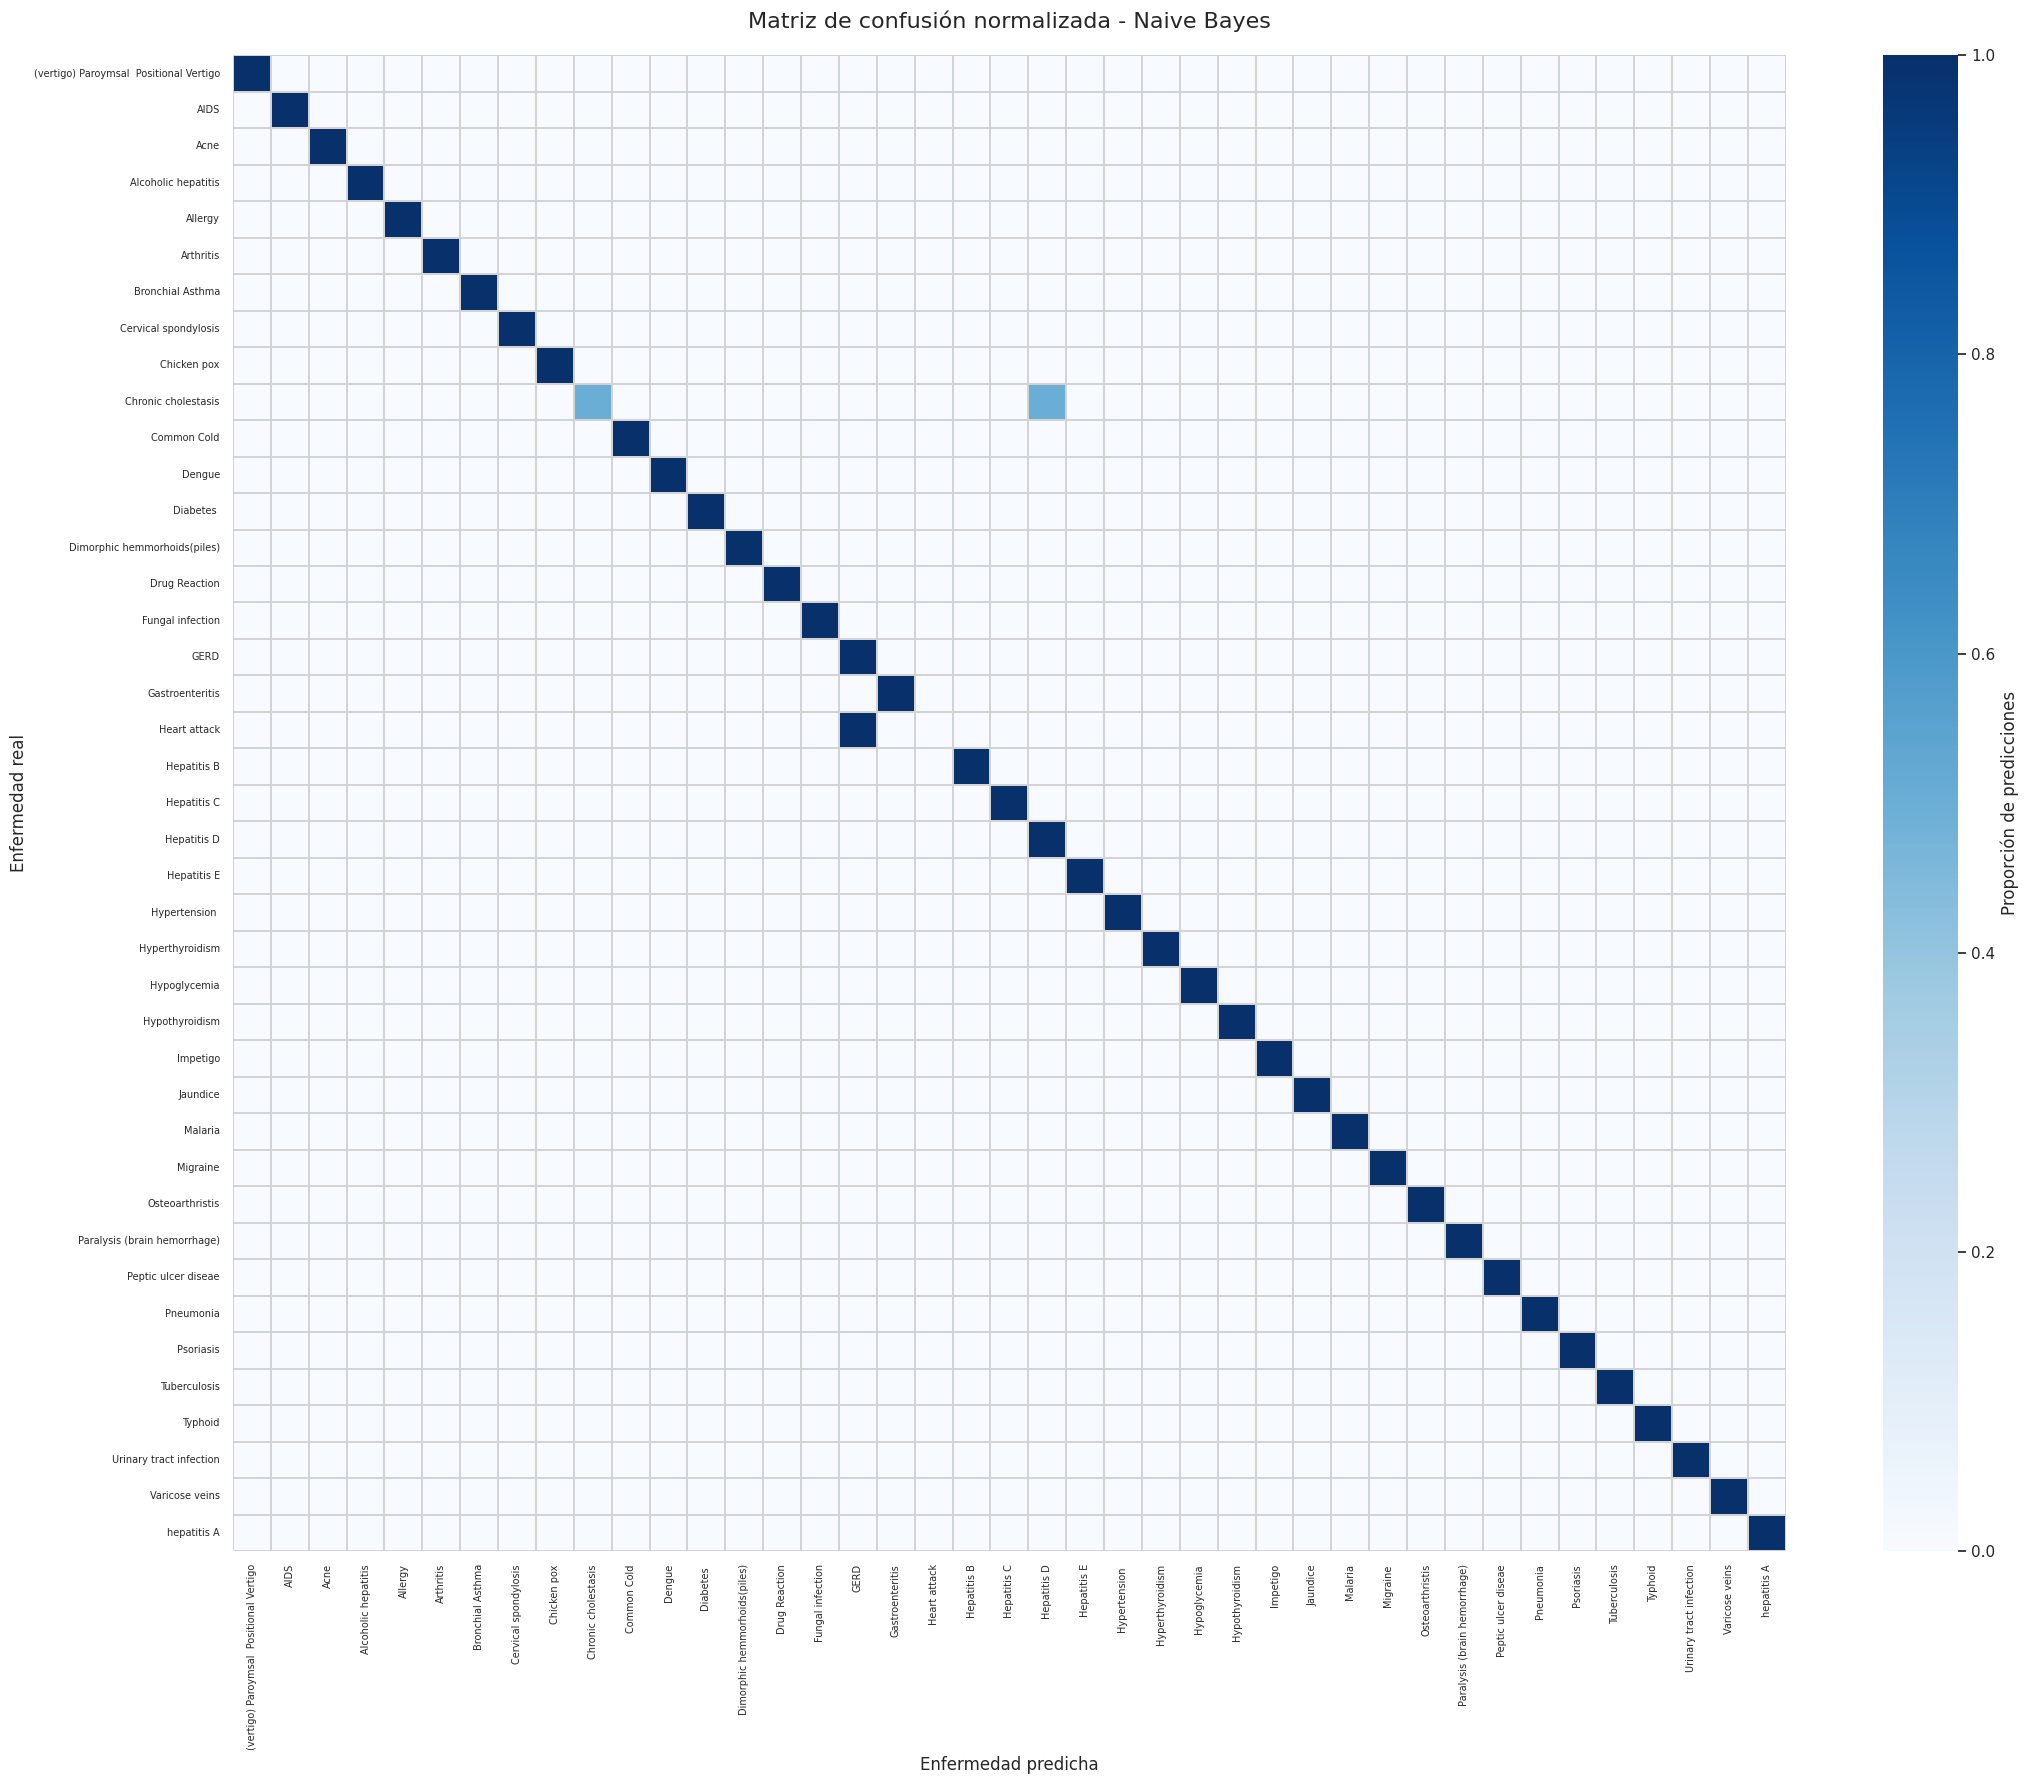

In [ ]:
"""Matriz de confusion normalizada por enfermedad real"""
matriz_normalizada = confusion_matrix(
    y_test, y_pred,
    labels=modelo_nb_principal.classes_,
    normalize="true"
)

plt.figure(figsize=(22, 18))
sns.heatmap(
    matriz_normalizada, cmap="Blues",
    xticklabels=modelo_nb_principal.classes_,
    yticklabels=modelo_nb_principal.classes_,
    vmin=0, vmax=1, annot=False,
    linewidths=0.2, linecolor="lightgray",
    cbar_kws={"label": "Proporción de predicciones"}
)

plt.title("Matriz de confusión normalizada - Naive Bayes", fontsize=16, pad=20)
plt.xlabel("Enfermedad predicha", fontsize=12)
plt.ylabel("Enfermedad real", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

**8.8 Probar una predicción individual**

In [ ]:
"""Ejemplo con el primer paciente del conjunto de prueba"""
paciente = X_test.iloc[[0]]
prediccion = modelo_nb_principal.predict(paciente)
print("Enfermedad predicha:", prediccion[0])
print("Enfermedad real:", y_test.iloc[0])

Enfermedad predicha: Hepatitis B
Enfermedad real: Hepatitis B


# **9. Comparar los resultados de Apriori con Naive Bayes.**

<center>

**La idea es responder que:**

**¿Las enfermedades encontradas por las reglas de asociación coinciden con las enfermedades que el clasificador predice correctamente?**

**9.1 Ver las mejores reglas de Apriori**

In [ ]:
top_reglas_apriori = reglas_finales.copy()

top_reglas_apriori["enfermedad"] = (
    top_reglas_apriori["consequents"]
    .apply(
        lambda conjunto: list(conjunto)[0]
        .replace("disease_", "")
        .replace("_", " ")
        .title()
    )
)

top_reglas_apriori[
    ["antecedents", "enfermedad", "support", "confidence", "lift"]
]

,antecedents,enfermedad,support,confidence,lift
3235,"(dizziness, back_pain)",Cervical Spondylosis,0.013158,1.0,50.666667
3741,"(high_fever, blister)",Impetigo,0.013158,1.0,50.666667
4211,"(bloody_stool, constipation)",Dimorphic Hemmorhoids(Piles),0.013158,1.0,50.666667
5463,"(burning_micturition, itching)",Drug Reaction,0.013158,1.0,50.666667
5805,"(dizziness, chest_pain)",Hypertension,0.013158,1.0,50.666667
10205,"(movement_stiffness, muscle_weakness)",Arthritis,0.013158,1.0,50.666667
1629,"(indigestion, abdominal_pain)",Peptic Ulcer Diseae,0.016447,1.0,43.428571
2482,"(chest_pain, acidity)",Gerd,0.016447,1.0,43.428571
4781,"(breathlessness, family_history)",Bronchial Asthma,0.016447,1.0,43.428571
10065,"(spinning_movements, headache)",(Vertigo) Paroymsal Positional Vertigo,0.016447,1.0,43.428571


**9.2 Crear tabla de predicciones de Naive Bayes**

In [ ]:
comparacion_nb = pd.DataFrame({"enfermedad_real": y_test.reset_index(drop=True), "enfermedad_predicha": y_pred})
comparacion_nb["acierto"] = (comparacion_nb["enfermedad_real"] == comparacion_nb["enfermedad_predicha"])
comparacion_nb.head()

,enfermedad_real,enfermedad_predicha,acierto
0,Hepatitis B,Hepatitis B,True
1,Pneumonia,Pneumonia,True
2,Drug Reaction,Drug Reaction,True
3,Allergy,Allergy,True
4,Pneumonia,Pneumonia,True


**9.3 Calcular aciertos por enfermedad**

In [ ]:
resumen_nb = comparacion_nb.groupby("enfermedad_real")["acierto"].mean().reset_index()
resumen_nb = resumen_nb.rename(columns={"enfermedad_real": "enfermedad", "acierto": "tasa_acierto_por_enfermedad"})
resumen_nb = resumen_nb.sort_values(by="tasa_acierto_por_enfermedad", ascending=False)

resumen_nb.head(15)

,enfermedad,tasa_acierto_por_enfermedad
0,(vertigo) Paroymsal Positional Vertigo,1.0
1,AIDS,1.0
2,Acne,1.0
3,Alcoholic hepatitis,1.0
4,Allergy,1.0
5,Arthritis,1.0
6,Bronchial Asthma,1.0
7,Cervical spondylosis,1.0
8,Chicken pox,1.0
10,Common Cold,1.0


In [ ]:
resumen_nb.sort_values(by="tasa_acierto_por_enfermedad", ascending=True).head(10)

,enfermedad,tasa_acierto_por_enfermedad
18,Heart attack,0.0
9,Chronic cholestasis,0.5
0,(vertigo) Paroymsal Positional Vertigo,1.0
1,AIDS,1.0
4,Allergy,1.0
5,Arthritis,1.0
2,Acne,1.0
3,Alcoholic hepatitis,1.0
8,Chicken pox,1.0
10,Common Cold,1.0


**9.4 Grafico para visualizar las enfermedades con menor tasa de acierto**

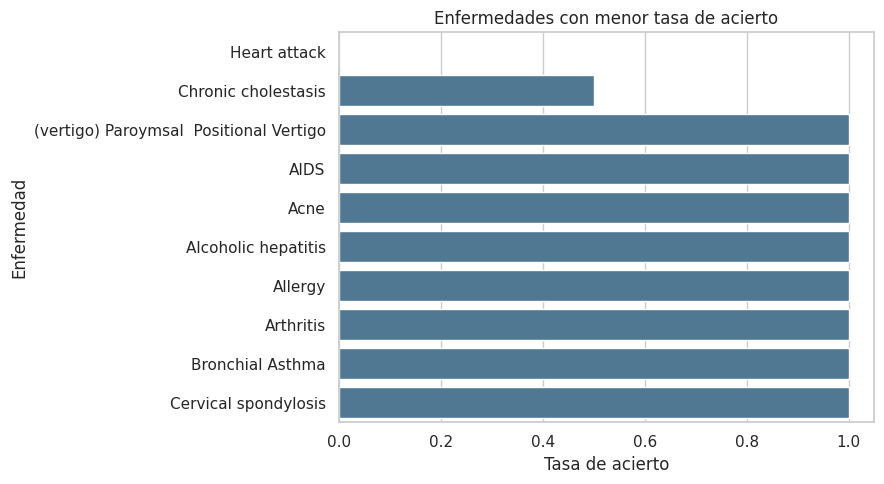

In [ ]:
desempeno_bajo = resumen_nb.nsmallest(10, "tasa_acierto_por_enfermedad")

plt.figure(figsize=(9, 5))
sns.barplot(data=desempeno_bajo, x="tasa_acierto_por_enfermedad", y="enfermedad", color="#457B9D")
plt.xlim(0, 1.05)
plt.title("Enfermedades con menor tasa de acierto")
plt.xlabel("Tasa de acierto")
plt.ylabel("Enfermedad")
plt.tight_layout()
plt.show()

**9.5 Comparacion textual**

In [ ]:
"""Creo una tabla para ver que enfermedades aparecen en Apriori"""
top_reglas_apriori["enfermedad"].value_counts()

,count
enfermedad,
Cervical Spondylosis,1
Impetigo,1
Dimorphic Hemmorhoids(Piles),1
Drug Reaction,1
Hypertension,1
Arthritis,1
Peptic Ulcer Diseae,1
Gerd,1
Bronchial Asthma,1


In [ ]:
"""Tabla para ver cuales clasifica mejor Naive Bayes"""
resumen_nb.head(15)

,enfermedad,tasa_acierto_por_enfermedad
0,(vertigo) Paroymsal Positional Vertigo,1.0
1,AIDS,1.0
2,Acne,1.0
3,Alcoholic hepatitis,1.0
4,Allergy,1.0
5,Arthritis,1.0
6,Bronchial Asthma,1.0
7,Cervical spondylosis,1.0
8,Chicken pox,1.0
10,Common Cold,1.0


In [ ]:
"""Ver si todas las enfermedades quedaron con 1.0"""
resumen_nb["tasa_acierto_por_enfermedad"].describe()

,tasa_acierto_por_enfermedad
count,41.000000
mean,0.963415
std,0.172853
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
"""Ver las enfermedades con menor precisión"""
resumen_nb.sort_values("tasa_acierto_por_enfermedad", ascending=True).head(10)

,enfermedad,tasa_acierto_por_enfermedad
18,Heart attack,0.0
9,Chronic cholestasis,0.5
0,(vertigo) Paroymsal Positional Vertigo,1.0
1,AIDS,1.0
4,Allergy,1.0
5,Arthritis,1.0
2,Acne,1.0
3,Alcoholic hepatitis,1.0
8,Chicken pox,1.0
10,Common Cold,1.0


# **10. Dataset complementario NHANES**

<center>

**Para complementar el análisis se utilizó NHANES 2013-2014, una encuesta pública con información anonimizada de participantes reales. El identificador `SEQN` permite reunir las condiciones médicas reportadas por una misma persona sin inventar pacientes.**

**NHANES se empleará exclusivamente para estudiar comorbilidad enfermedad-enfermedad. El análisis síntoma-enfermedad continuará realizándose con el dataset principal obligatorio**

**10.1 cargar dataset complementario**

In [ ]:
uploaded_nhanes = files.upload()

Saving archive.zip to archive (1).zip


**10.2 Descomprimir y revisar los archivo**

In [ ]:
nombre_zip_nhanes = list(uploaded_nhanes.keys())[0]
with zipfile.ZipFile(nombre_zip_nhanes, "r") as zip_ref: zip_ref.extractall("NHANES")
for carpeta, subcarpetas, archivos in os.walk("NHANES"):
    print("Carpeta:", carpeta)
    print("Archivos:", archivos)
    print()


Carpeta: NHANES
Archivos: ['demographic.csv', 'examination.csv', 'diet.csv', 'labs.csv', 'questionnaire.csv', 'medications.csv']



**10.3 Localizacion del archivo**

In [ ]:
ruta = "/content/NHANES"

In [ ]:
ruta_demografia = os.path.join(ruta, "demographic.csv")
ruta_cuestionario = os.path.join(ruta, "questionnaire.csv")

In [ ]:
print("Ruta demografía:", ruta_demografia)
print("Ruta cuestionario:", ruta_cuestionario)

Ruta demografía: /content/NHANES/demographic.csv
Ruta cuestionario: /content/NHANES/questionnaire.csv


In [ ]:
print("Existe demographic.csv:", os.path.exists(ruta_demografia))
print("Existe questionnaire.csv:", os.path.exists(ruta_cuestionario))

Existe demographic.csv: True
Existe questionnaire.csv: True


**10.4 Leer los archivos**

In [ ]:
demografia_nhanes = pd.read_csv(ruta_demografia)
cuestionario_nhanes = pd.read_csv(ruta_cuestionario)

In [ ]:
print("Dimensiones de demografía:", demografia_nhanes.shape)
print("Dimensiones del cuestionario:", cuestionario_nhanes.shape)

display(demografia_nhanes.head())
display(cuestionario_nhanes.head())

Dimensiones de demografía: (10175, 47)
Dimensiones del cuestionario: (10175, 953)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,73557,8,2,1,69,NaN,4,4,1.0,NaN,1.0,1.0,1,1.0,NaN,NaN,3.0,4.0,NaN,1,2.0,2,1.0,2.0,2.0,1.0,2.0,2.0,1.0,3,3,0,0,2,1,69,1.0,3.0,4.0,NaN,13281.237386,13481.042095,1,112,4.0,4.0,0.84
1,73558,8,2,1,54,NaN,3,3,1.0,NaN,2.0,NaN,1,1.0,NaN,NaN,3.0,1.0,NaN,1,2.0,2,1.0,2.0,2.0,1.0,2.0,2.0,1.0,4,4,0,2,0,1,54,1.0,3.0,1.0,1.0,23682.057386,24471.769625,1,108,7.0,7.0,1.78
2,73559,8,2,1,72,NaN,3,3,2.0,NaN,1.0,1.0,1,1.0,NaN,NaN,4.0,1.0,NaN,1,2.0,2,1.0,2.0,2.0,1.0,2.0,2.0,NaN,2,2,0,0,2,1,72,1.0,4.0,1.0,3.0,57214.803319,57193.285376,1,109,10.0,10.0,4.51
3,73560,8,2,1,9,NaN,3,3,1.0,119.0,NaN,NaN,1,1.0,NaN,3.0,NaN,NaN,NaN,1,1.0,2,1.0,2.0,2.0,1.0,2.0,2.0,1.0,4,4,0,2,0,1,33,1.0,3.0,1.0,4.0,55201.178592,55766.512438,2,109,9.0,9.0,2.52
4,73561,8,2,2,73,NaN,3,3,1.0,NaN,2.0,NaN,1,1.0,NaN,NaN,5.0,1.0,NaN,1,2.0,2,1.0,2.0,2.0,1.0,2.0,2.0,NaN,2,2,0,0,2,1,78,1.0,5.0,1.0,5.0,63709.667069,65541.871229,2,116,15.0,15.0,5.00


,SEQN,ACD011A,ACD011B,ACD011C,ACD040,ACD110,ALQ101,ALQ110,ALQ120Q,ALQ120U,ALQ130,ALQ141Q,ALQ141U,ALQ151,ALQ160,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ056,BPD058,BPQ059,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D,CBD070,CBD090,CBD110,CBD120,CBD130,HSD010,HSQ500,HSQ510,HSQ520,HSQ571,HSQ580,HSQ590,HSAQUEX,CSQ010,CSQ020,CSQ030,CSQ040,CSQ060,CSQ070,CSQ080,CSQ090A,CSQ090B,CSQ090C,CSQ090D,CSQ100,CSQ110,CSQ120A,CSQ120B,CSQ120C,CSQ120D,CSQ120E,CSQ120F,CSQ120G,CSQ120H,CSQ140,CSQ160,CSQ170,CSQ180,CSQ190,CSQ200,CSQ202,CSQ204,CSQ210,CSQ220,CSQ240,CSQ250,CSQ260,AUQ136,AUQ138,CDQ001,CDQ002,CDQ003,CDQ004,CDQ005,CDQ006,CDQ009A,CDQ009B,CDQ009C,CDQ009D,CDQ009E,CDQ009F,CDQ009G,CDQ009H,CDQ008,CDQ010,DIQ010,DID040,DIQ160,DIQ170,DIQ172,DIQ175A,DIQ175B,DIQ175C,DIQ175D,DIQ175E,DIQ175F,DIQ175G,DIQ175H,DIQ175I,DIQ175J,DIQ175K,DIQ175L,DIQ175M,DIQ175N,DIQ175O,DIQ175P,DIQ175Q,DIQ175R,DIQ175S,DIQ175T,DIQ175U,DIQ175V,DIQ175W,DIQ175X,DIQ180,DIQ050,DID060,DIQ060U,DIQ070,DIQ230,DIQ240,DID250,DID260,DIQ260U,DIQ275,DIQ280,DIQ291,DIQ300S,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080,DBQ010,DBD030,DBD041,DBD050,DBD055,DBD061,DBQ073A,DBQ073B,DBQ073C,DBQ073D,DBQ073E,DBQ073U,DBQ700,DBQ197,DBQ223A,DBQ223B,DBQ223C,DBQ223D,DBQ223E,DBQ223U,DBQ229,DBQ235A,DBQ235B,DBQ235C,DBQ301,DBQ330,DBQ360,DBQ370,DBD381,DBQ390,DBQ400,DBD411,DBQ421,DBQ424,DBD895,DBD900,DBD905,DBD910,CBQ596,CBQ606,CBQ611,CBQ505,CBQ535,CBQ540,CBQ545,CBQ550,CBQ552,CBQ580,CBQ585,CBQ590,DED031,DEQ034A,DEQ034C,DEQ034D,DEQ038G,DEQ038Q,DED120,DED125,DLQ010,DLQ020,DLQ040,DLQ050,DLQ060,DLQ080,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100,DUQ200,DUQ210,DUQ211,DUQ213,DUQ215Q,DUQ215U,DUQ217,DUQ219,DUQ220Q,DUQ220U,DUQ230,DUQ240,DUQ250,DUQ260,DUQ270Q,DUQ270U,DUQ272,DUQ280,DUQ290,DUQ300,DUQ310Q,DUQ310U,DUQ320,DUQ330,DUQ340,DUQ350Q,DUQ350U,DUQ352,DUQ360,DUQ370,DUQ380A,DUQ380B,DUQ380C,DUQ380D,DUQ380E,DUQ390,DUQ400Q,DUQ400U,DUQ410,DUQ420,DUQ430,ECD010,ECQ020,ECD070A,ECD070B,ECQ080,ECQ090,WHQ030E,MCQ080E,ECQ150,FSD032A,FSD032B,FSD032C,FSD041,FSD052,FSD061,FSD071,FSD081,FSD092,FSD102,FSD032D,FSD032E,FSD032F,FSD111,FSD122,FSD132,FSD141,FSD146,FSDHH,FSDAD,FSDCH,FSD151,FSQ165,FSQ012,FSD012N,FSD230,FSD225,FSQ235,FSQ162,FSD650ZC,FSD660ZC,FSD675,FSD680,FSD670ZC,FSQ690,FSQ695,FSD650ZW,FSD660ZW,FSD670ZW,HEQ010,HEQ020,HEQ030,HEQ040,HIQ011,HIQ031A,HIQ031B,HIQ031C,HIQ031D,HIQ031E,HIQ031F,HIQ031G,HIQ031H,HIQ031I,HIQ031J,HIQ031AA,HIQ260,HIQ105,HIQ270,HIQ210,HOD050,HOQ065,HUQ010,HUQ020,HUQ030,HUQ041,HUQ051,HUQ061,HUQ071,HUD080,HUQ090,IMQ011,IMQ020,IMQ040,IMQ070,IMQ080,IMQ090,IMQ045,INQ020,INQ012,INQ030,INQ060,INQ080,INQ090,INQ132,INQ140,INQ150,IND235,INDFMMPI,INDFMMPC,INQ244,IND247,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,AGQ030,MCQ053,MCQ070,MCQ075,MCQ080,MCQ082,MCQ084,MCQ086,MCQ092,MCD093,MCQ149,MCQ151,MCQ160A,MCQ180A,MCQ195,MCQ160N,MCQ180N,MCQ160B,MCQ180B,MCQ160C,MCQ180C,MCQ160D,MCQ180D,MCQ160E,MCQ180E,MCQ160F,MCQ180F,MCQ160G,MCQ180G,MCQ160M,MCQ170M,MCQ180M,MCQ160K,MCQ170K,MCQ180K,MCQ160L,MCQ170L,MCQ180L,MCQ160O,MCQ203,MCQ206,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240AA,MCQ240B,MCQ240BB,MCQ240C,MCQ240CC,MCQ240D,MCQ240DD,MCQ240DK,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,OCD150,OCQ180,OCQ210,OCQ260,OCD270,OCQ380,OCD390G,OCD395,OHQ030,OHQ033,OHQ770,OHQ780A,OHQ780B,OHQ780C,OHQ780D,OHQ780E,OHQ780F,OHQ780G,OHQ780H,OHQ780I,OHQ780J,OHQ780K,OHQ555G,OHQ555Q,OHQ555U,OHQ560G,OHQ560Q,OHQ560U,OHQ565,OHQ570Q,OHQ570U,OHQ575G,OHQ575Q,OHQ575U,OHQ580,OHQ585Q,OHQ585U,OHQ590G,OHQ590Q,OHQ590U,OHQ610,OHQ612,OHQ614,OHQ620,OHQ640,OHQ680,OHQ835,OHQ845,OHQ848G,OHQ848Q,OHQ849,OHQ850,OHQ855,OHQ860,OHQ865,OHQ870,OHQ875,OHQ880,OHQ885,OHQ895,OHQ900,OSQ010A,OSQ010B,OSQ010C,OSQ020A,OSQ020B,OSQ020C,OSD030AA,OSQ040AA,OSD050AA,OSD030AB,OSQ040AB,OSD050AB,OSD030AC,OSQ040AC,OSD050AC,OSD030BA,OSQ040BA

**10.5 Revisar la estructura de los archivos**

In [ ]:
"""Revisar demografia"""
demografia_nhanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Data columns (total 47 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SEQN      10175 non-null  int64  
 1   SDDSRVYR  10175 non-null  int64  
 2   RIDSTATR  10175 non-null  int64  
 3   RIAGENDR  10175 non-null  int64  
 4   RIDAGEYR  10175 non-null  int64  
 5   RIDAGEMN  673 non-null    float64
 6   RIDRETH1  10175 non-null  int64  
 7   RIDRETH3  10175 non-null  int64  
 8   RIDEXMON  9813 non-null   float64
 9   RIDEXAGM  4213 non-null   float64
 10  DMQMILIZ  6261 non-null   float64
 11  DMQADFC   543 non-null    float64
 12  DMDBORN4  10175 non-null  int64  
 13  DMDCITZN  10171 non-null  float64
 14  DMDYRSUS  1908 non-null   float64
 15  DMDEDUC3  2803 non-null   float64
 16  DMDEDUC2  5769 non-null   float64
 17  DMDMARTL  5769 non-null   float64
 18  RIDEXPRG  1309 non-null   float64
 19  SIALANG   10175 non-null  int64  
 20  SIAPROXY  10174 non-null  fl

In [ ]:
cuestionario_nhanes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10175 entries, 0 to 10174
Columns: 953 entries, SEQN to WHQ520
dtypes: float64(944), int64(7), object(2)
memory usage: 74.0+ MB


In [ ]:
resumen_nhanes = pd.DataFrame({
    "Archivo": ["Demografía", "Cuestionario"],
    "Filas": [demografia_nhanes.shape[0], cuestionario_nhanes.shape[0]],
    "Columnas": [demografia_nhanes.shape[1], cuestionario_nhanes.shape[1]]
})

resumen_nhanes

,Archivo,Filas,Columnas
0,Demografía,10175,47
1,Cuestionario,10175,953


**10.6 Normalizar los nombres de columnas**

In [ ]:
demografia_nhanes.columns = demografia_nhanes.columns.str.strip().str.upper()
cuestionario_nhanes.columns = cuestionario_nhanes.columns.str.strip().str.upper()

**10.7 Verificar el identificador de participante**

In [ ]:
print("SEQN en demografía:", "SEQN" in demografia_nhanes.columns)
print("SEQN en cuestionario:", "SEQN" in cuestionario_nhanes.columns)
print("Identificadores únicos en demografía:", demografia_nhanes["SEQN"].nunique())
print("Identificadores únicos en cuestionario:", cuestionario_nhanes["SEQN"].nunique())

SEQN en demografía: True
SEQN en cuestionario: True
Identificadores únicos en demografía: 10175
Identificadores únicos en cuestionario: 10175


**10.8 Revisar identificadores duplicados**

In [ ]:
print("SEQN duplicados en demografía:", demografia_nhanes["SEQN"].duplicated().sum())
print("SEQN duplicados en cuestionario:", cuestionario_nhanes["SEQN"].duplicated().sum())

SEQN duplicados en demografía: 0
SEQN duplicados en cuestionario: 0


**10.9 Revisar coincidencia de participantes**

In [ ]:
participantes_comunes = set(demografia_nhanes["SEQN"]).intersection(cuestionario_nhanes["SEQN"])
print("Participantes presentes en ambos archivos:", len(participantes_comunes))

Participantes presentes en ambos archivos: 10175


**10.10 Unir demografía y cuestionario**

In [ ]:
df_nhanes = demografia_nhanes.merge(
    cuestionario_nhanes,
    on="SEQN",
    how="inner",
    suffixes=("_demo", "_cuest")
)

print("Dimensiones de la base unificada:", df_nhanes.shape)
display(df_nhanes.head())

Dimensiones de la base unificada: (10175, 999)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,ACD011A,ACD011B,ACD011C,ACD040,ACD110,ALQ101,ALQ110,ALQ120Q,ALQ120U,ALQ130,ALQ141Q,ALQ141U,ALQ151,ALQ160,BPQ020,BPQ030,BPD035,BPQ040A,BPQ050A,BPQ056,BPD058,BPQ059,BPQ080,BPQ060,BPQ070,BPQ090D,BPQ100D,CBD070,CBD090,CBD110,CBD120,CBD130,HSD010,HSQ500,HSQ510,HSQ520,HSQ571,HSQ580,HSQ590,HSAQUEX,CSQ010,CSQ020,CSQ030,CSQ040,CSQ060,CSQ070,CSQ080,CSQ090A,CSQ090B,CSQ090C,CSQ090D,CSQ100,CSQ110,CSQ120A,CSQ120B,CSQ120C,CSQ120D,CSQ120E,CSQ120F,CSQ120G,CSQ120H,CSQ140,CSQ160,CSQ170,CSQ180,CSQ190,CSQ200,CSQ202,CSQ204,CSQ210,CSQ220,CSQ240,CSQ250,CSQ260,AUQ136,AUQ138,CDQ001,CDQ002,CDQ003,CDQ004,CDQ005,CDQ006,CDQ009A,CDQ009B,CDQ009C,CDQ009D,CDQ009E,CDQ009F,CDQ009G,CDQ009H,CDQ008,CDQ010,DIQ010,DID040,DIQ160,DIQ170,DIQ172,DIQ175A,DIQ175B,DIQ175C,DIQ175D,DIQ175E,DIQ175F,DIQ175G,DIQ175H,DIQ175I,DIQ175J,DIQ175K,DIQ175L,DIQ175M,DIQ175N,DIQ175O,DIQ175P,DIQ175Q,DIQ175R,DIQ175S,DIQ175T,DIQ175U,DIQ175V,DIQ175W,DIQ175X,DIQ180,DIQ050,DID060,DIQ060U,DIQ070,DIQ230,DIQ240,DID250,DID260,DIQ260U,DIQ275,DIQ280,DIQ291,DIQ300S,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080,DBQ010,DBD030,DBD041,DBD050,DBD055,DBD061,DBQ073A,DBQ073B,DBQ073C,DBQ073D,DBQ073E,DBQ073U,DBQ700,DBQ197,DBQ223A,DBQ223B,DBQ223C,DBQ223D,DBQ223E,DBQ223U,DBQ229,DBQ235A,DBQ235B,DBQ235C,DBQ301,DBQ330,DBQ360,DBQ370,DBD381,DBQ390,DBQ400,DBD411,DBQ421,DBQ424,DBD895,DBD900,DBD905,DBD910,CBQ596,CBQ606,CBQ611,CBQ505,CBQ535,CBQ540,CBQ545,CBQ550,CBQ552,CBQ580,CBQ585,CBQ590,DED031,DEQ034A,DEQ034C,DEQ034D,DEQ038G,DEQ038Q,DED120,DED125,DLQ010,DLQ020,DLQ040,DLQ050,DLQ060,DLQ080,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100,DUQ200,DUQ210,DUQ211,DUQ213,DUQ215Q,DUQ215U,DUQ217,DUQ219,DUQ220Q,DUQ220U,DUQ230,DUQ240,DUQ250,DUQ260,DUQ270Q,DUQ270U,DUQ272,DUQ280,DUQ290,DUQ300,DUQ310Q,DUQ310U,DUQ320,DUQ330,DUQ340,DUQ350Q,DUQ350U,DUQ352,DUQ360,DUQ370,DUQ380A,DUQ380B,DUQ380C,DUQ380D,DUQ380E,DUQ390,DUQ400Q,DUQ400U,DUQ410,DUQ420,DUQ430,ECD010,ECQ020,ECD070A,ECD070B,ECQ080,ECQ090,WHQ030E,MCQ080E,ECQ150,FSD032A,FSD032B,FSD032C,FSD041,FSD052,FSD061,FSD071,FSD081,FSD092,FSD102,FSD032D,FSD032E,FSD032F,FSD111,FSD122,FSD132,FSD141,FSD146,FSDHH,FSDAD,FSDCH,FSD151,FSQ165,FSQ012,FSD012N,FSD230,FSD225,FSQ235,FSQ162,FSD650ZC,FSD660ZC,FSD675,FSD680,FSD670ZC,FSQ690,FSQ695,FSD650ZW,FSD660ZW,FSD670ZW,HEQ010,HEQ020,HEQ030,HEQ040,HIQ011,HIQ031A,HIQ031B,HIQ031C,HIQ031D,HIQ031E,HIQ031F,HIQ031G,HIQ031H,HIQ031I,HIQ031J,HIQ031AA,HIQ260,HIQ105,HIQ270,HIQ210,HOD050,HOQ065,HUQ010,HUQ020,HUQ030,HUQ041,HUQ051,HUQ061,HUQ071,HUD080,HUQ090,IMQ011,IMQ020,IMQ040,IMQ070,IMQ080,IMQ090,IMQ045,INQ020,INQ012,INQ030,INQ060,INQ080,INQ090,INQ132,INQ140,INQ150,IND235,INDFMMPI,INDFMMPC,INQ244,IND247,MCQ010,MCQ025,MCQ035,MCQ040,MCQ050,AGQ030,MCQ053,MCQ070,MCQ075,MCQ080,MCQ082,MCQ084,MCQ086,MCQ092,MCD093,MCQ149,MCQ151,MCQ160A,MCQ180A,MCQ195,MCQ160N,MCQ180N,MCQ160B,MCQ180B,MCQ160C,MCQ180C,MCQ160D,MCQ180D,MCQ160E,MCQ180E,MCQ160F,MCQ180F,MCQ160G,MCQ180G,MCQ160M,MCQ170M,MCQ180M,MCQ160K,MCQ170K,MCQ180K,MCQ160L,MCQ170L,MCQ180L,MCQ160O,MCQ203,MCQ206,MCQ220,MCQ230A,MCQ230B,MCQ230C,MCQ230D,MCQ240A,MCQ240AA,MCQ240B,MCQ240BB,MCQ240C,MCQ240CC,MCQ240D,MCQ240DD,MCQ240DK,MCQ240E,MCQ240F,MCQ240G,MCQ240H,MCQ240I,MCQ240J,MCQ240K,MCQ240L,MCQ240M,MCQ240N,MCQ240O,MCQ240P,MCQ240Q,MCQ240R,MCQ240S,MCQ240T,MCQ240U,MCQ240V,MCQ240W,MCQ240X,MCQ240Y,MCQ240Z,MCQ300A,MCQ300B,MCQ300C,MCQ365A,MCQ365B,MCQ365C,MCQ365D,MCQ370A,MCQ370B,MCQ370C,MCQ370D,MCQ380,OCD150,OCQ180,OCQ210,OCQ260,OCD270,OCQ380,OCD390G,OCD395,OHQ030,OHQ033,OHQ770,OHQ780A,OHQ780B,OHQ780C,OHQ780D,OHQ780E,OHQ780F,OHQ780G,OHQ780H,OHQ780I,OHQ780J,OHQ780K,OHQ555G,OHQ555Q,OHQ555U,OHQ5

**Los archivos de demografía y cuestionario fueron unidos mediante SEQN, que representa el identificador anónimo de cada participante. La unión conserva únicamente personas presentes en ambos archivos y no crea registros artificiales.**

# **11. Comprensión y preparación de NHANES**

**11.1 Seleccionar variables de enfermedades**

In [ ]:
variables_enfermedades = {
    "MCQ010": "Asma",
    "MCQ070": "Psoriasis",
    "MCQ160A": "Artritis",
    "MCQ160B": "Insuficiencia cardiaca",
    "MCQ160C": "Enfermedad coronaria",
    "MCQ160D": "Angina",
    "MCQ160E": "Ataque cardiaco",
    "MCQ160F": "Accidente cerebrovascular",
    "MCQ160G": "Enfisema",
    "MCQ160K": "Bronquitis cronica",
    "MCQ160L": "Enfermedad hepatica",
    "MCQ160M": "Problema tiroideo",
    "MCQ160N": "Gota",
    "MCQ160O": "EPOC",
    "DIQ010": "Diabetes",
    "BPQ020": "Hipertension"
}

**11.2 Verificar que variables existen**

In [ ]:
variables_disponibles = {
    codigo: enfermedad for codigo, enfermedad in variables_enfermedades.items()
    if codigo in df_nhanes.columns
}

variables_no_encontradas = [
    codigo for codigo in variables_enfermedades
    if codigo not in df_nhanes.columns
]

print("Cantidad de variables encontradas:", len(variables_disponibles))
print("\nVariables disponibles:")
display(variables_disponibles)
print("\nVariables no encontradas:")
print(variables_no_encontradas)

Cantidad de variables encontradas: 16

Variables disponibles:


{'MCQ010': 'Asma',
 'MCQ070': 'Psoriasis',
 'MCQ160A': 'Artritis',
 'MCQ160B': 'Insuficiencia cardiaca',
 'MCQ160C': 'Enfermedad coronaria',
 'MCQ160D': 'Angina',
 'MCQ160E': 'Ataque cardiaco',
 'MCQ160F': 'Accidente cerebrovascular',
 'MCQ160G': 'Enfisema',
 'MCQ160K': 'Bronquitis cronica',
 'MCQ160L': 'Enfermedad hepatica',
 'MCQ160M': 'Problema tiroideo',
 'MCQ160N': 'Gota',
 'MCQ160O': 'EPOC',
 'DIQ010': 'Diabetes',
 'BPQ020': 'Hipertension'}


Variables no encontradas:
[]


**11.3  Crear la base de participantes con respuestas válidas**

<center>

**Se seleccionaron el identificador SEQN y las variables médicas disponibles. Se conservaron los participantes que respondieron afirmativa o negativamente al menos una de las preguntas seleccionadas.**

In [ ]:
codigos_enfermedades = list(variables_disponibles.keys())
columnas_comorbilidad = ["SEQN"] + codigos_enfermedades

df_base_comorbilidad = df_nhanes[columnas_comorbilidad].copy()

print("Dimensiones antes del filtro:", df_base_comorbilidad.shape)

Dimensiones antes del filtro: (10175, 17)


In [ ]:
"""Identifica las respuestas validas"""
respuesta_valida = df_base_comorbilidad[codigos_enfermedades].isin([1, 2]).any(axis=1)

df_base_comorbilidad = (
    df_base_comorbilidad[respuesta_valida]
    .reset_index(drop=True)
    .copy()
)

print("Participantes con respuestas validas:", len(df_base_comorbilidad))

Participantes con respuestas validas: 9768


In [ ]:
"""Revisar los primeros registros"""
display(df_base_comorbilidad.head())

,SEQN,MCQ010,MCQ070,MCQ160A,MCQ160B,MCQ160C,MCQ160D,MCQ160E,MCQ160F,MCQ160G,MCQ160K,MCQ160L,MCQ160M,MCQ160N,MCQ160O,DIQ010,BPQ020
0,73557,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0
1,73558,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0
2,73559,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0
3,73560,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
4,73561,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0


**11.4 Crear lista de enfermedades**

Cada respuesta con valor 1 fue interpretada como una condición reportada. Las respuestas negativas, desconocidas o ausentes no fueron agregadas a la lista.

In [ ]:
def crear_lista_enfermedades(fila):
    enfermedades = []

    for codigo, nombre in variables_disponibles.items():
        if fila[codigo] == 1:
            enfermedades.append(nombre)

    return enfermedades

In [ ]:
df_base_comorbilidad["lista_enfermedades"] = df_base_comorbilidad.apply(
    crear_lista_enfermedades,
    axis=1
)

display(df_base_comorbilidad[["SEQN", "lista_enfermedades"]].head(15))

,SEQN,lista_enfermedades
0,73557,"[Artritis, Accidente cerebrovascular, Diabetes..."
1,73558,"[Asma, Diabetes, Hipertension]"
2,73559,"[Diabetes, Hipertension]"
3,73560,[]
4,73561,"[Artritis, Bronquitis cronica, Problema tiroid..."
5,73562,"[Artritis, Enfermedad coronaria, Ataque cardia..."
6,73564,"[Asma, Artritis, Hipertension]"
7,73565,[]
8,73566,"[Artritis, Gota]"
9,73567,[Enfisema]


**11.5  Contar enfermedades reportadas por participante**

<center>

**Se contó la cantidad de condiciones presentes en cada lista. Este cálculo permite distinguir participantes sin enfermedades seleccionadas, con una sola enfermedad y con comorbilidad.**

In [ ]:
df_base_comorbilidad["cantidad_enfermedades"] = (
    df_base_comorbilidad["lista_enfermedades"].apply(len)
)

In [ ]:
"""Mostar resumen"""
cantidad = df_base_comorbilidad["cantidad_enfermedades"]

sin_enfermedades = (cantidad == 0).sum()
una_enfermedad = (cantidad == 1).sum()
dos_o_mas = (cantidad >= 2).sum()

print("Sin enfermedades seleccionadas:", sin_enfermedades)
print("Con una enfermedad:", una_enfermedad)
print("Con dos o más enfermedades:", dos_o_mas)
print("Total comprobado:", sin_enfermedades + una_enfermedad + dos_o_mas)
print("Total de participantes:", len(df_base_comorbilidad))

Sin enfermedades seleccionadas: 5494
Con una enfermedad: 2199
Con dos o más enfermedades: 2075
Total comprobado: 9768
Total de participantes: 9768


In [ ]:
"""Comprobacion adicional"""
df_base_comorbilidad["cantidad_enfermedades"].value_counts().sort_index()

,count
cantidad_enfermedades,
0,5494
1,2199
2,925
3,549
4,275
5,154
6,93
7,31
8,17


In [ ]:
"""Rvisa algunos participantes con comorbilidad"""
display(
    df_base_comorbilidad.loc[
        df_base_comorbilidad["cantidad_enfermedades"] >= 2,
        ["SEQN", "lista_enfermedades", "cantidad_enfermedades"]
    ].head(15)
)

,SEQN,lista_enfermedades,cantidad_enfermedades
0,73557,"[Artritis, Accidente cerebrovascular, Diabetes...",4
1,73558,"[Asma, Diabetes, Hipertension]",3
2,73559,"[Diabetes, Hipertension]",2
4,73561,"[Artritis, Bronquitis cronica, Problema tiroid...",4
5,73562,"[Artritis, Enfermedad coronaria, Ataque cardia...",6
6,73564,"[Asma, Artritis, Hipertension]",3
8,73566,"[Artritis, Gota]",2
12,73571,"[Ataque cardiaco, Diabetes, Hipertension]",3
37,73596,"[Asma, Problema tiroideo, Hipertension]",3
45,73604,"[Enfisema, Problema tiroideo]",2


**11.6 Crear el grupo descriptivo de comorbilidad**

<center>

**Se consideró que existe comorbilidad cuando una misma persona reportó dos o más enfermedades seleccionadas. Este grupo se utilizará para describir los casos, mientras que Apriori se calculará sobre los 9.768 participantes con respuestas válidas.**

In [ ]:
df_comorbilidad = (
    df_base_comorbilidad[
        df_base_comorbilidad["cantidad_enfermedades"] >= 2
    ]
    .reset_index(drop=True)
    .copy()
)

porcentaje = len(df_comorbilidad) / len(df_base_comorbilidad) * 100

print("Participantes con comorbilidad:", len(df_comorbilidad))
print("Porcentaje con comorbilidad:", f"{porcentaje:.2f}%")

Participantes con comorbilidad: 2075
Porcentaje con comorbilidad: 21.24%


**11.7 Crear tabla resumen**

In [ ]:
resumen_participantes = pd.DataFrame({
    "Grupo": [
        "Sin enfermedades seleccionadas",
        "Con una enfermedad",
        "Con dos o más enfermedades"
    ],
    "Participantes": [sin_enfermedades, una_enfermedad, dos_o_mas]
})

resumen_participantes["Porcentaje"] = (
    resumen_participantes["Participantes"] / len(df_base_comorbilidad) * 100
).round(2)

resumen_participantes

,Grupo,Participantes,Porcentaje
0,Sin enfermedades seleccionadas,5494,56.24
1,Con una enfermedad,2199,22.51
2,Con dos o más enfermedades,2075,21.24


**11.8 Graficar grupos de participantes**

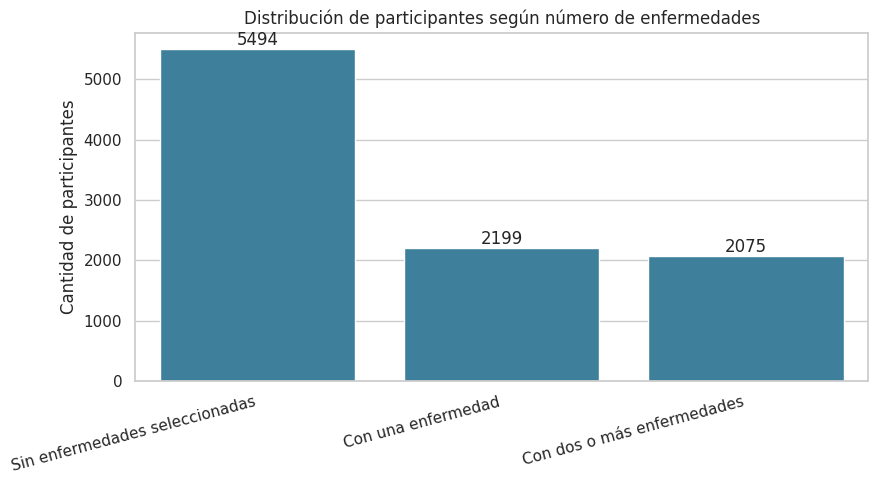

In [ ]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=resumen_participantes,
    x="Grupo",
    y="Participantes",
    color="#2E86AB"
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d")

plt.title("Distribución de participantes según número de enfermedades")
plt.xlabel("")
plt.ylabel("Cantidad de participantes")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()

plt.show()


**Interpretación:**

De los 9.768 participantes con respuestas válidas, 5.494 no reportaron las enfermedades seleccionadas, 2.199 reportaron una y 2.075 presentaron dos o más. Por tanto, el 21,24% pertenece al grupo descriptivo de comorbilidad.

**11.9 Graficar cantidad exacta de enfermedades**

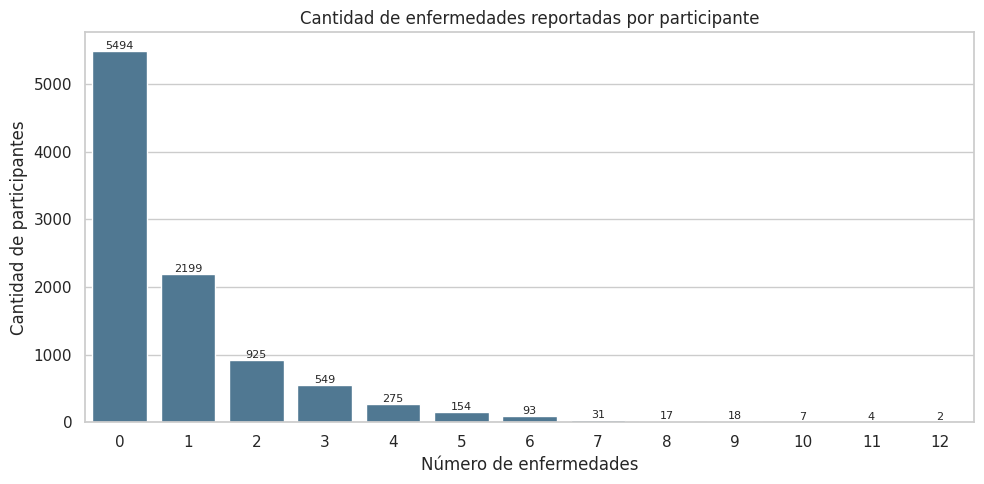

In [ ]:
"""La grafica mostra cuantas personas tienen cero, una, dos, tres o mas enfermedades"""
conteo_enfermedades = (
    df_base_comorbilidad["cantidad_enfermedades"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

ax = sns.barplot(x=conteo_enfermedades.index, y=conteo_enfermedades.values, color="#457B9D")

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d", fontsize=8)

plt.title("Cantidad de enfermedades reportadas por participante")
plt.xlabel("Número de enfermedades")
plt.ylabel("Cantidad de participantes")
plt.tight_layout()
plt.show()

**Interpretación:**

La mayor parte de los participantes reportó cero o una enfermedad seleccionada. Sin embargo, existe un grupo considerable con dos o más condiciones, lo que permite estudiar patrones reales de comorbilidad.

**11.10 Frecuencia de enfermedades**

In [ ]:
frecuencia_enfermedades_nhanes = (
    df_base_comorbilidad["lista_enfermedades"]
    .explode()
    .dropna()
    .value_counts()
)

tabla_frecuencia_nhanes = (
    frecuencia_enfermedades_nhanes
    .rename_axis("Enfermedad")
    .reset_index(name="Participantes")
)

tabla_frecuencia_nhanes["Porcentaje"] = (
    tabla_frecuencia_nhanes["Participantes"]
    / len(df_base_comorbilidad) * 100
).round(2)

tabla_frecuencia_nhanes

,Enfermedad,Participantes,Porcentaje
0,Hipertension,2174,22.26
1,Asma,1538,15.75
2,Artritis,1508,15.44
3,Diabetes,737,7.55
4,Problema tiroideo,601,6.15
5,Bronquitis cronica,320,3.28
6,Enfermedad hepatica,234,2.40
7,Gota,234,2.40
8,Enfermedad coronaria,232,2.38
9,Ataque cardiaco,230,2.35


**11.11 Grafico: Frecuencia de enfermedades reportadas en NHANES**

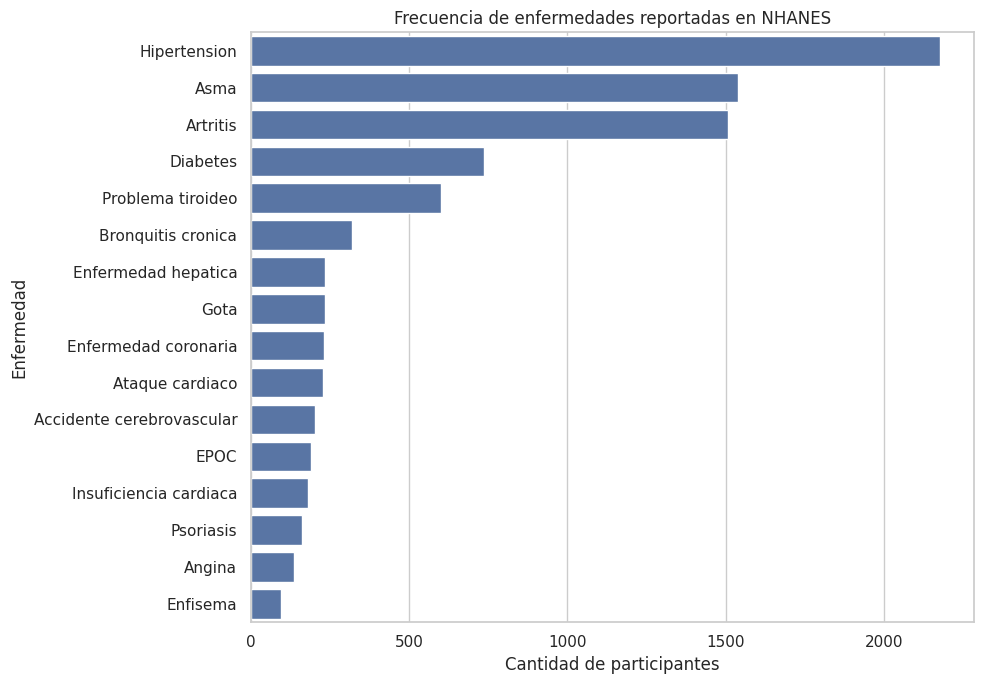

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=tabla_frecuencia_nhanes,
    x="Participantes",
    y="Enfermedad",
)

plt.title("Frecuencia de enfermedades reportadas en NHANES")
plt.xlabel("Cantidad de participantes")
plt.ylabel("Enfermedad")
plt.tight_layout()
plt.show()

**Interpretación:**

La gráfica muestra las enfermedades más reportadas entre los participantes. Las condiciones frecuentes pueden aparecer en varias asociaciones, por lo que su presencia debe evaluarse junto con el soporte, la confianza y el lift.

In [ ]:
"""Comprobación antes de Apriori"""
print("Participantes usados como base de Apriori:", len(df_base_comorbilidad))
print("Participantes con comorbilidad descriptiva:", len(df_comorbilidad))
print("Enfermedades disponibles:", len(variables_disponibles))
print("Máxima cantidad de enfermedades en una persona:",
    df_base_comorbilidad["cantidad_enfermedades"].max()
)

Participantes usados como base de Apriori: 9768
Participantes con comorbilidad descriptiva: 2075
Enfermedades disponibles: 16
Máxima cantidad de enfermedades en una persona: 12


# **12. Minería de comorbilidad enfermedad-enfermedad**

Cada participante fue representado como una transacción formada por las enfermedades que reportó. Los participantes sin diagnósticos positivos se conservaron porque también forman parte de la población con respuestas válidas.

Posteriormente, las transacciones fueron convertidas a formato binario y analizadas con dos configuraciones de Apriori.

**12.1 Crear una transacción por participante**

In [ ]:
transacciones_comorbilidad = df_base_comorbilidad["lista_enfermedades"].apply(
    lambda lista: [
        f"disease_{enfermedad.lower().replace(' ', '_')}"
        for enfermedad in lista
    ]
).tolist()

print("Cantidad de transacciones:", len(transacciones_comorbilidad))
print("\nPrimeras cinco transacciones:")

for transaccion in transacciones_comorbilidad[:5]:
    print(transaccion)

Cantidad de transacciones: 9768

Primeras cinco transacciones:
['disease_artritis', 'disease_accidente_cerebrovascular', 'disease_diabetes', 'disease_hipertension']
['disease_asma', 'disease_diabetes', 'disease_hipertension']
['disease_diabetes', 'disease_hipertension']
[]
['disease_artritis', 'disease_bronquitis_cronica', 'disease_problema_tiroideo', 'disease_hipertension']


**12.2 Comprobar transacciones vacías**

In [ ]:
transacciones_vacias = sum(len(t) == 0 for t in transacciones_comorbilidad)
transacciones_con_enfermedades = sum(len(t) >= 1 for t in transacciones_comorbilidad)

print("Transacciones vacías:", transacciones_vacias)
print("Transacciones con enfermedades:", transacciones_con_enfermedades)
print("Total:", len(transacciones_comorbilidad))

Transacciones vacías: 5494
Transacciones con enfermedades: 4274
Total: 9768


**12.3 Transformar las transacciones a formato binario**

In [ ]:
te_comorbilidad = TransactionEncoder()

datos_comorbilidad = te_comorbilidad.fit(
    transacciones_comorbilidad
).transform(transacciones_comorbilidad)

df_transacciones_comorbilidad = pd.DataFrame(
    datos_comorbilidad,
    columns=te_comorbilidad.columns_
)

print("Dimensiones de la matriz binaria:", df_transacciones_comorbilidad.shape)
display(df_transacciones_comorbilidad.head())

Dimensiones de la matriz binaria: (9768, 16)


,disease_accidente_cerebrovascular,disease_angina,disease_artritis,disease_asma,disease_ataque_cardiaco,disease_bronquitis_cronica,disease_diabetes,disease_enfermedad_coronaria,disease_enfermedad_hepatica,disease_enfisema,disease_epoc,disease_gota,disease_hipertension,disease_insuficiencia_cardiaca,disease_problema_tiroideo,disease_psoriasis
0,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False


In [ ]:
"""Comprobar que todas las columnas sean booleanas"""
print("Tipos de datos utilizados:")
print(df_transacciones_comorbilidad.dtypes.value_counts())

Tipos de datos utilizados:
bool    16
Name: count, dtype: int64


**12.4 Comprobar la cantidad de enfermedades**

In [ ]:
print("Enfermedades representadas en la matriz:", df_transacciones_comorbilidad.shape[1])
print("\nColumnas:")
print(df_transacciones_comorbilidad.columns.tolist())

Enfermedades representadas en la matriz: 16

Columnas:
['disease_accidente_cerebrovascular', 'disease_angina', 'disease_artritis', 'disease_asma', 'disease_ataque_cardiaco', 'disease_bronquitis_cronica', 'disease_diabetes', 'disease_enfermedad_coronaria', 'disease_enfermedad_hepatica', 'disease_enfisema', 'disease_epoc', 'disease_gota', 'disease_hipertension', 'disease_insuficiencia_cardiaca', 'disease_problema_tiroideo', 'disease_psoriasis']


In [ ]:
"""Coincide"""
len(variables_disponibles)

16

In [ ]:
"""Comprobar"""
print("Variables disponibles:", len(variables_disponibles))
print("Columnas binarias:", df_transacciones_comorbilidad.shape[1])

Variables disponibles: 16
Columnas binarias: 16


**12.5 Aplicar primera configuración de Apriori**

La primera configuración utilizó soporte mínimo de 0,01 y confianza mínima de 0,40. Se eligieron valores conservadores para priorizar asociaciones presentes en al menos el 1% de los participantes.

In [ ]:
itemsets_comorbilidad_1 = apriori(
    df_transacciones_comorbilidad,
    min_support=0.01,
    use_colnames=True,
    max_len=2,
    low_memory=True
)

print("Itemsets frecuentes de la configuración 1:",len(itemsets_comorbilidad_1))

display(
    itemsets_comorbilidad_1
    .sort_values(by="support", ascending=False)
    .head(15)
)

Itemsets frecuentes de la configuración 1: 44


,support,itemsets
11,0.222563,(disease_hipertension)
3,0.157453,(disease_asma)
2,0.154382,(disease_artritis)
26,0.095106,"(disease_hipertension, disease_artritis)"
6,0.075450,(disease_diabetes)
13,0.061527,(disease_problema_tiroideo)
36,0.051802,"(disease_hipertension, disease_diabetes)"
31,0.039005,"(disease_hipertension, disease_asma)"
18,0.034091,"(disease_artritis, disease_asma)"
43,0.032965,"(disease_hipertension, disease_problema_tiroideo)"


In [ ]:
"""Genera las reglas"""
if len(itemsets_comorbilidad_1) > 0:
    reglas_comorbilidad_1 = association_rules(
        itemsets_comorbilidad_1,
        metric="confidence",
        min_threshold=0.40
    )
else:
    reglas_comorbilidad_1 = pd.DataFrame()

print("Reglas de la configuración 1:",len(reglas_comorbilidad_1))

Reglas de la configuración 1: 26


In [ ]:
if not reglas_comorbilidad_1.empty:
    display(
        reglas_comorbilidad_1[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ]
        .sort_values(["lift", "confidence", "support"], ascending=False)
        .head(15)
    )
else:
    print("La primera configuración no produjo reglas.")

,antecedents,consequents,support,confidence,lift
16,(disease_ataque_cardiaco),(disease_enfermedad_coronaria),0.011364,0.482609,20.319490
15,(disease_enfermedad_coronaria),(disease_ataque_cardiaco),0.011364,0.478448,20.319490
8,(disease_epoc),(disease_artritis),0.012899,0.656250,4.250829
12,(disease_insuficiencia_cardiaca),(disease_artritis),0.011159,0.598901,3.879354
9,(disease_gota),(disease_artritis),0.014128,0.589744,3.820037
4,(disease_bronquitis_cronica),(disease_artritis),0.018939,0.578125,3.744778
24,(disease_insuficiencia_cardiaca),(disease_hipertension),0.015254,0.818681,3.678417
20,(disease_enfermedad_coronaria),(disease_hipertension),0.018939,0.797414,3.582860
3,(disease_ataque_cardiaco),(disease_artritis),0.012899,0.547826,3.548518
6,(disease_enfermedad_coronaria),(disease_artritis),0.013002,0.547414,3.545847


**12.6 Segunda configuración de Apriori**

La segunda configuración utilizó soporte mínimo de 0,005 y confianza mínima de 0,30. Estos valores permiten detectar asociaciones menos frecuentes, sin dejar de exigir una relación mínima entre las enfermedades.

In [ ]:
itemsets_comorbilidad_2 = apriori(
    df_transacciones_comorbilidad,
    min_support=0.005,
    use_colnames=True,
    max_len=3,
    low_memory=True
)

print("Itemsets frecuentes de la configuración 2:", len(itemsets_comorbilidad_2))

display(
    itemsets_comorbilidad_2
    .sort_values(by="support", ascending=False)
    .head(15)
)

Itemsets frecuentes de la configuración 2: 108


,support,itemsets
12,0.222563,(disease_hipertension)
3,0.157453,(disease_asma)
2,0.154382,(disease_artritis)
32,0.095106,"(disease_hipertension, disease_artritis)"
6,0.075450,(disease_diabetes)
14,0.061527,(disease_problema_tiroideo)
56,0.051802,"(disease_hipertension, disease_diabetes)"
41,0.039005,"(disease_hipertension, disease_asma)"
23,0.034091,"(disease_artritis, disease_asma)"
67,0.032965,"(disease_hipertension, disease_problema_tiroideo)"


In [ ]:
"""Generar las reglas"""
if len(itemsets_comorbilidad_2) > 0:
    reglas_comorbilidad_2 = association_rules(
        itemsets_comorbilidad_2,
        metric="confidence",
        min_threshold=0.30
    )
else:
    reglas_comorbilidad_2 = pd.DataFrame()

print("Reglas de la configuración 2:", len(reglas_comorbilidad_2))

Reglas de la configuración 2: 148


In [ ]:
if not reglas_comorbilidad_2.empty:
    display(
        reglas_comorbilidad_2[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ]
        .sort_values(["lift", "confidence", "support"], ascending=False)
        .head(15)
    )
else:
    print("La segunda configuración no produjo reglas.")

,antecedents,consequents,support,confidence,lift
40,(disease_enfisema),(disease_epoc),0.006962,0.715789,36.415789
41,(disease_epoc),(disease_enfisema),0.006962,0.354167,36.415789
57,"(disease_angina, disease_hipertension)",(disease_enfermedad_coronaria),0.006143,0.600000,25.262069
59,(disease_angina),"(disease_hipertension, disease_enfermedad_coro...",0.006143,0.441176,23.294118
58,"(disease_hipertension, disease_enfermedad_coro...",(disease_angina),0.006143,0.324324,23.294118
5,(disease_angina),(disease_enfermedad_coronaria),0.007678,0.551471,23.218813
6,(disease_enfermedad_coronaria),(disease_angina),0.007678,0.323276,23.218813
123,"(disease_hipertension, disease_ataque_cardiaco)",(disease_enfermedad_coronaria),0.009419,0.522727,22.008621
125,(disease_enfermedad_coronaria),"(disease_hipertension, disease_ataque_cardiaco)",0.009419,0.396552,22.008621
122,"(disease_hipertension, disease_enfermedad_coro...",(disease_ataque_cardiaco),0.009419,0.497297,21.120000


**12.7 Comparación de las configuraciones**

In [ ]:
comparacion_apriori_nhanes = pd.DataFrame({
    "Configuración": ["Conservadora", "Flexible"],
    "Soporte mínimo": [0.01, 0.005],
    "Confianza mínima": [0.40, 0.30],
    "Longitud máxima": [2, 3],
    "Itemsets encontrados": [
        len(itemsets_comorbilidad_1),
        len(itemsets_comorbilidad_2)
    ],
    "Reglas encontradas": [
        len(reglas_comorbilidad_1),
        len(reglas_comorbilidad_2)
    ]
})

comparacion_apriori_nhanes

,Configuración,Soporte mínimo,Confianza mínima,Longitud máxima,Itemsets encontrados,Reglas encontradas
0,Conservadora,0.010,0.4,2,44,26
1,Flexible,0.005,0.3,3,108,148


**12.8 Graficar la comparación**

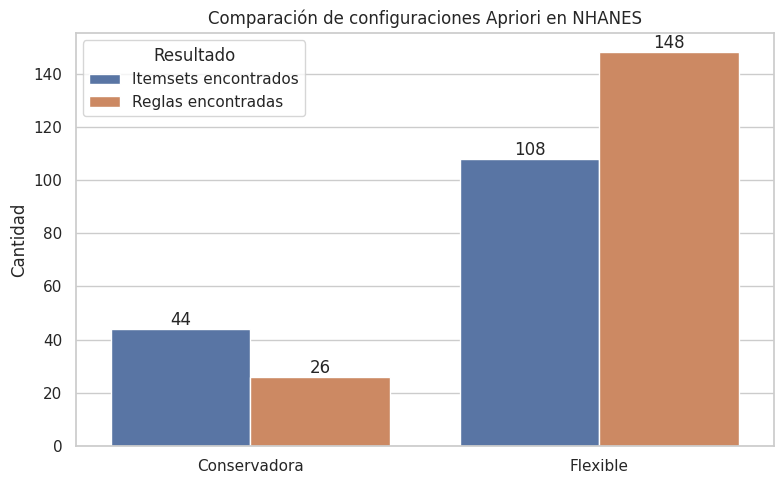

In [ ]:
datos_grafico_nhanes = comparacion_apriori_nhanes.melt(
    id_vars="Configuración",
    value_vars=["Itemsets encontrados", "Reglas encontradas"],
    var_name="Resultado",
    value_name="Cantidad"
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=datos_grafico_nhanes,
    x="Configuración",
    y="Cantidad",
    hue="Resultado"
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%d")

plt.title("Comparación de configuraciones Apriori en NHANES")
plt.xlabel("")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

**Interpretación:**

La configuración conservadora prioriza asociaciones con mayor presencia, mientras que la flexible permite descubrir patrones menos frecuentes. La selección final se realizará con la segunda configuración y filtros adicionales de soporte, confianza y lift.

In [ ]:
print("RESUMEN DEL PROCESO")
print("-" * 50)
print("Participantes analizados:", len(df_base_comorbilidad))
print("Enfermedades disponibles:", df_transacciones_comorbilidad.shape[1])
print("Itemsets configuración 1:", len(itemsets_comorbilidad_1))
print("Reglas configuración 1:", len(reglas_comorbilidad_1))
print("Itemsets configuración 2:", len(itemsets_comorbilidad_2))
print("Reglas configuración 2:", len(reglas_comorbilidad_2))

RESUMEN DEL PROCESO
--------------------------------------------------
Participantes analizados: 9768
Enfermedades disponibles: 16
Itemsets configuración 1: 44
Reglas configuración 1: 26
Itemsets configuración 2: 108
Reglas configuración 2: 148


# **13. Evaluación de reglas de comorbilidad**

Las reglas de la configuración flexible fueron filtradas mediante soporte, confianza y lift. Primero se estudiaron asociaciones simples entre dos enfermedades y después se conservaron las reglas múltiples como un análisis adicional.

Las reglas representan asociaciones estadísticas y no demuestran que una enfermedad sea la causa de otra.

**13.1 Verificar reglas disponibles**

In [ ]:
print("Reglas disponibles en la configuración flexible:", len(reglas_comorbilidad_2))

if reglas_comorbilidad_2.empty:
    print("No existen reglas para evaluar.")
else:
    display(
        reglas_comorbilidad_2[
            ["antecedents", "consequents", "support", "confidence", "lift"]
        ]
        .sort_values(["lift", "confidence", "support"], ascending=False)
        .head(15)
    )

Reglas disponibles en la configuración flexible: 148


,antecedents,consequents,support,confidence,lift
40,(disease_enfisema),(disease_epoc),0.006962,0.715789,36.415789
41,(disease_epoc),(disease_enfisema),0.006962,0.354167,36.415789
57,"(disease_angina, disease_hipertension)",(disease_enfermedad_coronaria),0.006143,0.600000,25.262069
59,(disease_angina),"(disease_hipertension, disease_enfermedad_coro...",0.006143,0.441176,23.294118
58,"(disease_hipertension, disease_enfermedad_coro...",(disease_angina),0.006143,0.324324,23.294118
5,(disease_angina),(disease_enfermedad_coronaria),0.007678,0.551471,23.218813
6,(disease_enfermedad_coronaria),(disease_angina),0.007678,0.323276,23.218813
123,"(disease_hipertension, disease_ataque_cardiaco)",(disease_enfermedad_coronaria),0.009419,0.522727,22.008621
125,(disease_enfermedad_coronaria),"(disease_hipertension, disease_ataque_cardiaco)",0.009419,0.396552,22.008621
122,"(disease_hipertension, disease_enfermedad_coro...",(disease_ataque_cardiaco),0.009419,0.497297,21.120000


**13. 2 Filtrar asociaciones simples enfermedad-enfermedad**

Se conservaron reglas con una enfermedad en el antecedente y una enfermedad en el consecuente. También se exigió un lift superior a uno.

In [ ]:
reglas_comorbilidad = reglas_comorbilidad_2.copy()

reglas_comorbilidad_pares = (
    reglas_comorbilidad[
        (reglas_comorbilidad["lift"] > 1)
        & (reglas_comorbilidad["antecedents"].apply(len) == 1)
        & (reglas_comorbilidad["consequents"].apply(len) == 1)
    ]
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .copy()
)

print("Reglas simples enfermedad-enfermedad:", len(reglas_comorbilidad_pares))

Reglas simples enfermedad-enfermedad: 48


In [ ]:
display(
    reglas_comorbilidad_pares[
        ["antecedents", "consequents", "support", "confidence", "lift"]
    ].head(15)
)

,antecedents,consequents,support,confidence,lift
40,(disease_enfisema),(disease_epoc),0.006962,0.715789,36.415789
41,(disease_epoc),(disease_enfisema),0.006962,0.354167,36.415789
5,(disease_angina),(disease_enfermedad_coronaria),0.007678,0.551471,23.218813
6,(disease_enfermedad_coronaria),(disease_angina),0.007678,0.323276,23.218813
26,(disease_ataque_cardiaco),(disease_enfermedad_coronaria),0.011364,0.482609,20.319490
25,(disease_enfermedad_coronaria),(disease_ataque_cardiaco),0.011364,0.478448,20.319490
4,(disease_angina),(disease_ataque_cardiaco),0.005733,0.411765,17.487468
28,(disease_insuficiencia_cardiaca),(disease_ataque_cardiaco),0.007371,0.395604,16.801147
29,(disease_ataque_cardiaco),(disease_insuficiencia_cardiaca),0.007371,0.313043,16.801147
37,(disease_enfermedad_coronaria),(disease_insuficiencia_cardiaca),0.007166,0.301724,16.193634


**13.3 Convertir las reglas a nombres legibles**

In [ ]:
def limpiar_enfermedad_nhanes(conjunto):
    enfermedad = list(conjunto)[0]

    return (
        enfermedad
        .replace("disease_", "")
        .replace("_", " ")
        .title()
    )

In [ ]:
reglas_comorbilidad_pares["Enfermedad antecedente"] = (
    reglas_comorbilidad_pares["antecedents"].apply(limpiar_enfermedad_nhanes)
)

reglas_comorbilidad_pares["Enfermedad asociada"] = (
    reglas_comorbilidad_pares["consequents"].apply(limpiar_enfermedad_nhanes)
)

In [ ]:
display(
    reglas_comorbilidad_pares[
        [
            "Enfermedad antecedente",
            "Enfermedad asociada",
            "support",
            "confidence",
            "lift"
        ]
    ].head(15)
)

,Enfermedad antecedente,Enfermedad asociada,support,confidence,lift
40,Enfisema,Epoc,0.006962,0.715789,36.415789
41,Epoc,Enfisema,0.006962,0.354167,36.415789
5,Angina,Enfermedad Coronaria,0.007678,0.551471,23.218813
6,Enfermedad Coronaria,Angina,0.007678,0.323276,23.218813
26,Ataque Cardiaco,Enfermedad Coronaria,0.011364,0.482609,20.319490
25,Enfermedad Coronaria,Ataque Cardiaco,0.011364,0.478448,20.319490
4,Angina,Ataque Cardiaco,0.005733,0.411765,17.487468
28,Insuficiencia Cardiaca,Ataque Cardiaco,0.007371,0.395604,16.801147
29,Ataque Cardiaco,Insuficiencia Cardiaca,0.007371,0.313043,16.801147
37,Enfermedad Coronaria,Insuficiencia Cardiaca,0.007166,0.301724,16.193634


**13.4 Identificar reglas reflejadas**

In [ ]:
reglas_comorbilidad_pares["Pareja"] = reglas_comorbilidad_pares.apply(
    lambda fila: " | ".join(sorted([
        fila["Enfermedad antecedente"],
        fila["Enfermedad asociada"]
    ])),
    axis=1
)

print("Reglas antes de eliminar reflejos:", len(reglas_comorbilidad_pares))
print("Parejas diferentes:", reglas_comorbilidad_pares["Pareja"].nunique())

Reglas antes de eliminar reflejos: 48
Parejas diferentes: 42


**13.5 Eliminar reglas reflejadas**

In [ ]:
reglas_comorbilidad_unicas = (
    reglas_comorbilidad_pares
    .sort_values(["confidence", "lift", "support"], ascending=False)
    .drop_duplicates(subset="Pareja", keep="first")
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .copy()
)

print("Reglas después de eliminar reflejos:", len(reglas_comorbilidad_unicas))

Reglas después de eliminar reflejos: 42


**13.6 Calcular participantes**

<center>

**El soporte fue calculado sobre los 9.768 participantes válidos**

In [ ]:
reglas_comorbilidad_unicas["Participantes con ambas enfermedades"] = (
    reglas_comorbilidad_unicas["support"] * len(df_base_comorbilidad)
).round().astype(int)

In [ ]:
display(
    reglas_comorbilidad_unicas[
        [
            "Enfermedad antecedente",
            "Enfermedad asociada",
            "support",
            "confidence",
            "lift",
            "Participantes con ambas enfermedades"
        ]
    ].head(15)
)

,Enfermedad antecedente,Enfermedad asociada,support,confidence,lift,Participantes con ambas enfermedades
40,Enfisema,Epoc,0.006962,0.715789,36.415789,68
5,Angina,Enfermedad Coronaria,0.007678,0.551471,23.218813,75
26,Ataque Cardiaco,Enfermedad Coronaria,0.011364,0.482609,20.319490,111
4,Angina,Ataque Cardiaco,0.005733,0.411765,17.487468,56
28,Insuficiencia Cardiaca,Ataque Cardiaco,0.007371,0.395604,16.801147,72
38,Insuficiencia Cardiaca,Enfermedad Coronaria,0.007166,0.384615,16.193634,70
30,Epoc,Bronquitis Cronica,0.007883,0.401042,12.241797,77
35,Insuficiencia Cardiaca,Diabetes,0.007473,0.401099,5.316057,73
24,Ataque Cardiaco,Diabetes,0.008804,0.373913,4.955743,86
1,Accidente Cerebrovascular,Diabetes,0.007576,0.366337,4.855327,74


**13.7 Seleccionar reglas finales**

<center>

Se conservaron reglas con soporte mínimo de 0,005, confianza mínima de 0,30 y lift superior a uno. Después de eliminar las asociaciones reflejadas, se seleccionaron hasta 15 parejas.

In [ ]:
reglas_comorbilidad_finales = (
    reglas_comorbilidad_unicas[
        (reglas_comorbilidad_unicas["support"] >= 0.005)
        & (reglas_comorbilidad_unicas["confidence"] >= 0.30)
        & (reglas_comorbilidad_unicas["lift"] > 1)
    ]
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .head(15)
    .copy()
)

print("Reglas finales seleccionadas:", len(reglas_comorbilidad_finales))

Reglas finales seleccionadas: 15


<center>

**Estas son solo las 15 reglas, Significa que solamente esa cantidad cumplió todos los criterios.**

**13.8 Crear tabla final**

In [ ]:
tabla_comorbilidad = reglas_comorbilidad_finales[
    [
        "Enfermedad antecedente",
        "Enfermedad asociada",
        "support",
        "confidence",
        "lift",
        "Participantes con ambas enfermedades"
    ]
].copy()

tabla_comorbilidad["Soporte (%)"] = (tabla_comorbilidad["support"] * 100).round(2)
tabla_comorbilidad["Confianza (%)"] = (tabla_comorbilidad["confidence"] * 100).round(2)
tabla_comorbilidad["Lift"] = tabla_comorbilidad["lift"].round(2)

tabla_comorbilidad = tabla_comorbilidad[
    [
        "Enfermedad antecedente",
        "Enfermedad asociada",
        "Soporte (%)",
        "Confianza (%)",
        "Lift",
        "Participantes con ambas enfermedades"
    ]
].reset_index(drop=True)

tabla_comorbilidad.index += 1
tabla_comorbilidad.index.name = "Regla"

tabla_comorbilidad

,Enfermedad antecedente,Enfermedad asociada,Soporte (%),Confianza (%),Lift,Participantes con ambas enfermedades
Regla,,,,,,
1,Enfisema,Epoc,0.70,71.58,36.42,68
2,Angina,Enfermedad Coronaria,0.77,55.15,23.22,75
3,Ataque Cardiaco,Enfermedad Coronaria,1.14,48.26,20.32,111
4,Angina,Ataque Cardiaco,0.57,41.18,17.49,56
5,Insuficiencia Cardiaca,Ataque Cardiaco,0.74,39.56,16.80,72
6,Insuficiencia Cardiaca,Enfermedad Coronaria,0.72,38.46,16.19,70
7,Epoc,Bronquitis Cronica,0.79,40.10,12.24,77
8,Insuficiencia Cardiaca,Diabetes,0.75,40.11,5.32,73
9,Ataque Cardiaco,Diabetes,0.88,37.39,4.96,86


**13.9 Mostrar reglas en texto**

In [ ]:
for numero, fila in tabla_comorbilidad.iterrows():
    print(
        f"Regla {numero}:\n"
        f"Entre los participantes que reportaron "
        f"{fila['Enfermedad antecedente']}, se encontró una asociación con "
        f"{fila['Enfermedad asociada']}.\n"
        f"El soporte fue de {fila['Soporte (%)']:.2f}%, "
        f"la confianza de {fila['Confianza (%)']:.2f}% "
        f"y el lift de {fila['Lift']:.2f}.\n"
        f"Ambas enfermedades aparecieron en "
        f"{fila['Participantes con ambas enfermedades']} participantes.\n"
    )

Regla 1:
Entre los participantes que reportaron Enfisema, se encontró una asociación con Epoc.
El soporte fue de 0.70%, la confianza de 71.58% y el lift de 36.42.
Ambas enfermedades aparecieron en 68 participantes.

Regla 2:
Entre los participantes que reportaron Angina, se encontró una asociación con Enfermedad Coronaria.
El soporte fue de 0.77%, la confianza de 55.15% y el lift de 23.22.
Ambas enfermedades aparecieron en 75 participantes.

Regla 3:
Entre los participantes que reportaron Ataque Cardiaco, se encontró una asociación con Enfermedad Coronaria.
El soporte fue de 1.14%, la confianza de 48.26% y el lift de 20.32.
Ambas enfermedades aparecieron en 111 participantes.

Regla 4:
Entre los participantes que reportaron Angina, se encontró una asociación con Ataque Cardiaco.
El soporte fue de 0.57%, la confianza de 41.18% y el lift de 17.49.
Ambas enfermedades aparecieron en 56 participantes.

Regla 5:
Entre los participantes que reportaron Insuficiencia Cardiaca, se encontró una a

**13.10 Graficar reglas finales**

<center>

**Visualización de los patrones de comorbilidad**

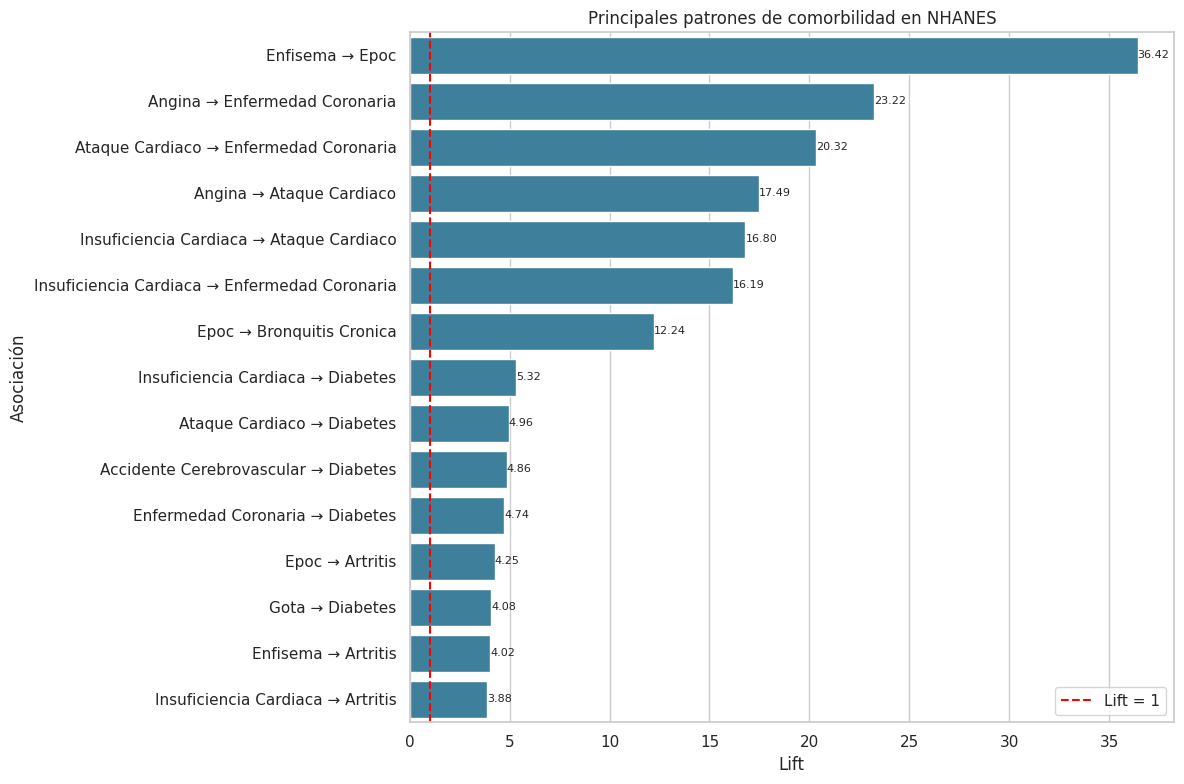

In [ ]:
tabla_grafico_comorbilidad = tabla_comorbilidad.copy()

tabla_grafico_comorbilidad["Asociación"] = (
    tabla_grafico_comorbilidad["Enfermedad antecedente"]
    + " → "
    + tabla_grafico_comorbilidad["Enfermedad asociada"]
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=tabla_grafico_comorbilidad,
    x="Lift",
    y="Asociación",
    color="#2E86AB"
)

for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f", fontsize=8)

plt.axvline(x=1, color="red", linestyle="--", label="Lift = 1")
plt.title("Principales patrones de comorbilidad en NHANES")
plt.xlabel("Lift")
plt.ylabel("Asociación")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:**

Las reglas seleccionadas presentan un lift superior a uno, lo que indica que las enfermedades aparecen juntas con mayor frecuencia de la esperada entre los participantes analizados. La dirección de la flecha representa la forma de la regla, pero no demuestra causalidad.

**13.11 Reglas de comorbilidad múltiple**

También se revisaron reglas en las que dos o más enfermedades aparecen asociadas con una tercera. Estas reglas se presentan por separado para no mezclarlas con las asociaciones simples.

In [ ]:
reglas_comorbilidad_multiple = (
    reglas_comorbilidad[
        (reglas_comorbilidad["antecedents"].apply(len) >= 2)
        & (reglas_comorbilidad["consequents"].apply(len) == 1)
        & (reglas_comorbilidad["lift"] > 1)
    ]
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .copy()
)

print("Reglas de comorbilidad múltiple:", len(reglas_comorbilidad_multiple))

Reglas de comorbilidad múltiple: 79


In [ ]:
display(
    reglas_comorbilidad_multiple[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(10)
)

,antecedents,consequents,support,confidence,lift
57,"(disease_angina, disease_hipertension)",(disease_enfermedad_coronaria),0.006143,0.600000,25.262069
58,"(disease_hipertension, disease_enfermedad_coro...",(disease_angina),0.006143,0.324324,23.294118
123,"(disease_hipertension, disease_ataque_cardiaco)",(disease_enfermedad_coronaria),0.009419,0.522727,22.008621
122,"(disease_hipertension, disease_enfermedad_coro...",(disease_ataque_cardiaco),0.009419,0.497297,21.120000
73,"(disease_artritis, disease_enfermedad_coronaria)",(disease_ataque_cardiaco),0.006245,0.480315,20.398768
74,"(disease_artritis, disease_ataque_cardiaco)",(disease_enfermedad_coronaria),0.006245,0.484127,20.383415
128,"(disease_hipertension, disease_ataque_cardiaco)",(disease_insuficiencia_cardiaca),0.006757,0.375000,20.126374
127,"(disease_hipertension, disease_insuficiencia_c...",(disease_ataque_cardiaco),0.006757,0.442953,18.812022
144,"(disease_hipertension, disease_enfermedad_coro...",(disease_insuficiencia_cardiaca),0.006347,0.335135,17.986813
145,"(disease_hipertension, disease_insuficiencia_c...",(disease_enfermedad_coronaria),0.006347,0.416107,17.519556


**13.12 Exportar resultados**

In [ ]:
tabla_comorbilidad.to_csv(
    "reglas_comorbilidad_nhanes.csv",
    index=True,
    encoding="utf-8-sig"
)

reglas_comorbilidad_multiple[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(10).to_csv(
    "reglas_comorbilidad_multiple_nhanes.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Resultados de comorbilidad exportados correctamente.")

Resultados de comorbilidad exportados correctamente.


# **14. Integración de los análisis**

 **Integración del análisis principal y NHANES**

Los dos datasets fueron analizados de forma independiente porque representan unidades diferentes. El dataset obligatorio contiene perfiles de síntomas asociados con una sola enfermedad, mientras que NHANES contiene participantes reales que pueden reportar varias enfermedades.

El uso de ambos datasets permite estudiar dos perspectivas: asociaciones síntoma-enfermedad y comorbilidad enfermedad-enfermedad.

**14.1 Crear comparación metodológica**

In [ ]:
comparacion_analisis = pd.DataFrame({
    "Aspecto": [
        "Dataset",
        "Unidad analizada",
        "Tipo de patrón",
        "Algoritmo principal",
        "Métricas",
        "Resultado",
        "Uso práctico"
    ],
    "Análisis principal": [
        "Disease Symptom Prediction",
        "Perfil único de síntomas",
        "Síntomas → Enfermedad",
        "Apriori y Naive Bayes",
        "Soporte, confianza, lift y exactitud",
        "15 reglas y clasificación",
        "Apoyo al triaje inicial"
    ],
    "Análisis de comorbilidad": [
        "NHANES 2013-2014",
        "Participante identificado por SEQN",
        "Enfermedad → Enfermedad",
        "Apriori",
        "Soporte, confianza y lift",
        "Patrones de comorbilidad",
        "Reconocimiento de condiciones simultáneas"
    ]
})

comparacion_analisis

,Aspecto,Análisis principal,Análisis de comorbilidad
0,Dataset,Disease Symptom Prediction,NHANES 2013-2014
1,Unidad analizada,Perfil único de síntomas,Participante identificado por SEQN
2,Tipo de patrón,Síntomas → Enfermedad,Enfermedad → Enfermedad
3,Algoritmo principal,Apriori y Naive Bayes,Apriori
4,Métricas,"Soporte, confianza, lift y exactitud","Soporte, confianza y lift"
5,Resultado,15 reglas y clasificación,Patrones de comorbilidad
6,Uso práctico,Apoyo al triaje inicial,Reconocimiento de condiciones simultáneas


**14.2 Resumen numérico**

In [ ]:
resumen_integrado = pd.DataFrame({
    "Indicador": [
        "Registros/perfiles analizados",
        "Participantes con comorbilidad",
        "Reglas finales",
        "Exactitud de Naive Bayes"
    ],
    "Dataset principal": [
        len(df_binario_sin_dup),
        "No aplica",
        len(tabla_reglas_finales),
        f"{accuracy_principal * 100:.2f}%"
    ],
    "NHANES": [
        len(df_base_comorbilidad),
        len(df_comorbilidad),
        len(tabla_comorbilidad),
        "No aplica"
    ]
})

resumen_integrado

,Indicador,Dataset principal,NHANES
0,Registros/perfiles analizados,304,9768
1,Participantes con comorbilidad,No aplica,2075
2,Reglas finales,15,15
3,Exactitud de Naive Bayes,96.72%,No aplica


**14.3 Comparar los métodos**

**Comparación de los hallazgos**

Apriori aplicado al dataset principal permitió reconocer combinaciones de síntomas asociadas con enfermedades específicas. Estas reglas son fáciles de explicar y pueden resumirse mediante tarjetas de alerta.

Naive Bayes utilizó los síntomas como variables predictoras y alcanzó una exactitud de 96,72%. Este resultado muestra una buena capacidad de clasificación dentro del conjunto de prueba, aunque no representa una garantía diagnóstica.

Por otra parte, Apriori aplicado a NHANES permitió encontrar enfermedades que aparecen simultáneamente en una misma persona. En este análisis no se buscó predecir una enfermedad, sino describir patrones de comorbilidad mediante soporte, confianza y lift.

Los resultados se complementan: el primer análisis estudia qué síntomas se relacionan con una enfermedad, mientras que el segundo estudia qué enfermedades aparecen juntas.

**14.4 Crear un esquema visual**

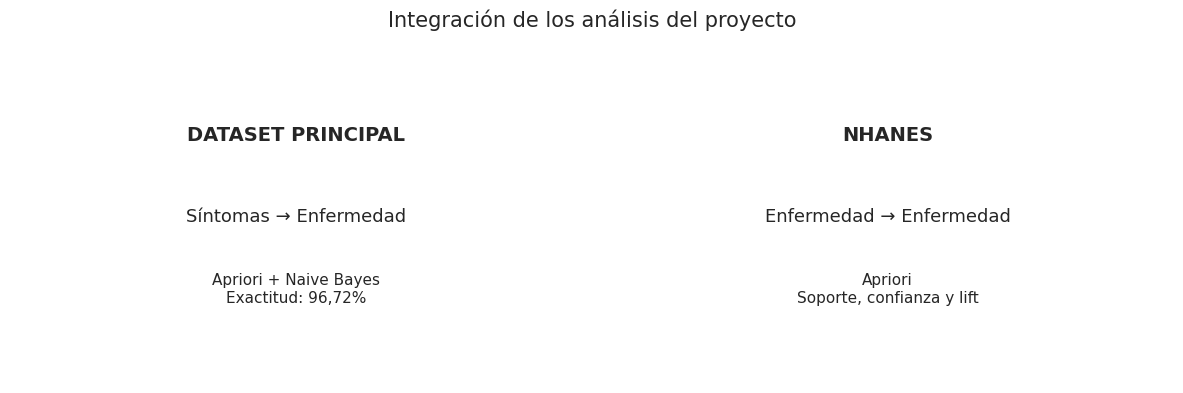

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].axis("off")
ax[0].text(0.5, 0.75, "DATASET PRINCIPAL", ha="center", fontsize=14, fontweight="bold")
ax[0].text(0.5, 0.50, "Síntomas → Enfermedad", ha="center", fontsize=13)
ax[0].text(0.5, 0.25, "Apriori + Naive Bayes\nExactitud: 96,72%", ha="center", fontsize=11)

ax[1].axis("off")
ax[1].text(0.5, 0.75, "NHANES", ha="center", fontsize=14, fontweight="bold")
ax[1].text(0.5, 0.50, "Enfermedad → Enfermedad", ha="center", fontsize=13)
ax[1].text(0.5, 0.25, "Apriori\nSoporte, confianza y lift", ha="center", fontsize=11)

plt.suptitle("Integración de los análisis del proyecto", fontsize=15)
plt.tight_layout()
plt.show()

**Interpretación:**

El dataset principal permite estudiar síntomas asociados con una enfermedad y evaluar un clasificador. NHANES permitir estudiar enfermedades simultáneas en participantes reales. Ambos análisis se complementan sin mezclar sus registros.

**14.5 Exportar comparación**

In [ ]:
comparacion_analisis.to_csv("comparacion_metodologica.csv", index=False, encoding="utf-8-sig")
resumen_integrado.to_csv("resumen_integrado.csv", index=False, encoding="utf-8-sig")
print("Comparación integrada exportada correctamente.")

Comparación integrada exportada correctamente.


# **15. Tarjetas de alerta para 5 enfermedades**

<center>

Enfermedad

Síntomas más asociados

Soporte

Confianza

Nivel de confiabilidad

Precauciones recomendadas

**15.1 Revisar columnas de precauciones**

In [ ]:
precauciones.head()

,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [ ]:
precauciones.columns

Index(['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3',
       'Precaution_4'],
      dtype='object')

**15.2 Seleccionar 5 enfermedades**

In [ ]:
reglas_para_tarjetas = reglas_finales.sort_values(by=["support", "confidence", "lift"], ascending=False).drop_duplicates(subset=["Enfermedad_item"], keep="first").head(5).copy()

reglas_para_tarjetas["Síntomas asociados"] = reglas_para_tarjetas["antecedents"].apply(limpiar_sintomas)
reglas_para_tarjetas["Enfermedad"] = reglas_para_tarjetas["consequents"].apply(limpiar_enfermedad)

tabla_tarjetas = reglas_para_tarjetas[["Síntomas asociados", "Enfermedad", "support", "confidence", "lift"]].copy()
tabla_tarjetas = tabla_tarjetas.rename(columns={"support": "Soporte", "confidence": "Confianza", "lift": "Lift"})

tabla_tarjetas

,Síntomas asociados,Enfermedad,Soporte,Confianza,Lift
2013,"abnormal menstruation, brittle nails",Hypothyroidism,0.026316,1.0,38.000000
12494,"muscle pain, sweating",Malaria,0.023026,1.0,38.000000
1629,"abdominal pain, indigestion",Peptic Ulcer Diseae,0.016447,1.0,43.428571
2482,"acidity, chest pain",Gerd,0.016447,1.0,43.428571
4781,"breathlessness, family history",Bronchial Asthma,0.016447,1.0,43.428571


In [ ]:
enfermedades_tarjetas = tabla_tarjetas["Enfermedad"].tolist()
enfermedades_tarjetas

['Hypothyroidism',
 'Malaria',
 'Peptic Ulcer Diseae',
 'Gerd',
 'Bronchial Asthma']

**15.3 Crear función para nivel de confiabilidad**

In [ ]:
def nivel_confiabilidad(confianza, soporte):
    if confianza >= 0.90 and soporte >= 0.05:
        return "Alta"
    elif confianza >= 0.70 and soporte >= 0.01:
        return "Media"
    else:
        return "Baja"

**15.4 Preparar precauciones**

In [ ]:
precauciones_limpias = precauciones.copy()

precauciones_limpias["Disease_limpia"] = (
    precauciones_limpias["Disease"]
    .astype(str)
    .str.lower()
    .str.strip()
)

**15.5 Crear tarjetas**

In [ ]:
columnas_precauciones = [
    columna
    for columna in precauciones_limpias.columns
    if "precaution" in columna.lower()
]

tarjetas = []

for enfermedad in enfermedades_tarjetas:
    regla = tabla_tarjetas[
        tabla_tarjetas["Enfermedad"] == enfermedad
    ].iloc[0]

    enfermedad_busqueda = enfermedad.lower().strip()

    fila_precaucion = precauciones_limpias[
        precauciones_limpias["Disease_limpia"]
        == enfermedad_busqueda
    ]

    if not fila_precaucion.empty:
        precs = (
            fila_precaucion.iloc[0][columnas_precauciones]
            .dropna()
            .astype(str)
            .tolist()
        )
    else:
        precs = ["No disponible en el dataset"]

    tarjetas.append({
        "Enfermedad": enfermedad,
        "Síntomas asociados": regla["Síntomas asociados"],
        "Soporte": regla["Soporte"],
        "Confianza": regla["Confianza"],
        "Lift": regla["Lift"],
        "Nivel de confiabilidad": nivel_confiabilidad(
            regla["Confianza"],
            regla["Soporte"]
        ),
        "Precauciones recomendadas": ", ".join(precs)
    })

tarjetas_alerta = pd.DataFrame(tarjetas)

tarjetas_alerta

,Enfermedad,Síntomas asociados,Soporte,Confianza,Lift,Nivel de confiabilidad,Precauciones recomendadas
0,Hypothyroidism,"abnormal menstruation, brittle nails",0.026316,1.0,38.000000,Media,"reduce stress, exercise, eat healthy, get prop..."
1,Malaria,"muscle pain, sweating",0.023026,1.0,38.000000,Media,"Consult nearest hospital, avoid oily food, avo..."
2,Peptic Ulcer Diseae,"abdominal pain, indigestion",0.016447,1.0,43.428571,Media,"avoid fatty spicy food, consume probiotic food..."
3,Gerd,"acidity, chest pain",0.016447,1.0,43.428571,Media,"avoid fatty spicy food, avoid lying down after..."
4,Bronchial Asthma,"breathlessness, family history",0.016447,1.0,43.428571,Media,"switch to loose cloothing, take deep breaths, ..."


**15.6 Guardar tarjetas**

In [ ]:
tarjetas_alerta.to_csv(
    "tarjetas_alerta.csv",
    index=False
)

print("Archivo tarjetas_alerta.csv creado correctamente.")

Archivo tarjetas_alerta.csv creado correctamente.
